# 03 — Análisis exploratorio

**TP Integrador · 82.04 Analítica Descriptiva (ITBA) · Grupo 2 · 2da pre-entrega**

Este notebook responde al tercer punto de la consigna: **estadísticos robustos y narrativa
visual**. Once gráficos, ninguno decorativo: cada uno abre con la pregunta que responde y
cierra con su lectura.

El hilo conductor es el cliente: una persona con ahorros en dólares que compra **una sola
unidad** para alquilarla. No puede diversificar, así que si elige mal no hay otra operación
que compense.

**Regla que ordena todo el notebook: comparar semejantes.** Un departamento con amenities
suele estar en un barrio caro y uno sin amenities, en uno barato. Una diferencia medida
sobre todo el mercado mezcla el atributo con la zona y el tamaño. Por eso toda afirmación
bivariada se verifica **dentro del estrato barrio × rango de superficie** y, donde el
tamaño muestral alcanza, también con el tipo de propiedad como control.

| Bloque | Pregunta del cliente | Gráficos |
|---|---|---|
| A | ¿Dónde rinde más, y cuánto me puedo fiar del número? | 05, 06, 07 |
| B | ¿Le gana el ladrillo a la alternativa? | 08 |
| C | ¿Qué atributos del inmueble mueven la renta, comparando semejantes? | 09, 10, 12, 13 |
| D | ¿Qué puedo comprar, y en qué mercado? | 11, 14, 15 |

Al final, las **hipótesis** H1, H3 y H4 se evalúan con el tamaño del efecto dentro del
estrato, y se declara qué test formal las va a contrastar en la 3ra entrega.

**Insumos:** `data/processed/dataset_analitico.csv` (`py src/kpis.py`), las tablas de
`data/external/` (`py src/fuentes_externas.py`) y las salidas de `py src/temporal.py` y
`py src/sesgo.py`.

**Salida:** `graficos/05_*.png` a `graficos/13_*.png`, `graficos/14_*.html` y `graficos/15_*.png`.

In [39]:
import os, sys, warnings
from pathlib import Path

# El kernel puede arrancar en la raiz del repo o en Entrega 2 (depende del
# editor). Se busca la carpeta notebooks/ para que ../src y ../data resuelvan
# siempre igual, sin importar desde donde se abra el notebook.
def _carpeta_notebooks() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        for cand in (base, base / "Entrega 2"):
            if (cand / "src" / "eda.py").exists():
                return cand / "notebooks"
    raise FileNotFoundError("No se encontro Entrega 2/src: abrir el notebook dentro del repo")

os.chdir(_carpeta_notebooks())
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import eda
import modelo_alquiler as M
import supuestos as S

eda.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=FutureWarning)

df = pd.read_csv("../data/processed/dataset_analitico.csv",
                 encoding="utf-8-sig", low_memory=False)

# Base de lectura de los KPIs: propiedades EN VENTA con estimacion confiable.
# Se excluyen los barrios con pocos alquileres, donde el modelo extrapola
# desde otros barrios y el numero no se sostiene.
ventas_kpi = df[(df.operacion == "venta") & df.rent_bruta_pct.notna()]
ok = ventas_kpi[ventas_kpi.estimacion_confiable == 1].copy()

print(f"dataset completo          : {len(df):,} filas x {df.shape[1]} columnas")
print(f"    en venta              : {int((df.operacion == 'venta').sum()):,}")
print(f"    en alquiler           : {int((df.operacion == 'alquiler').sum()):,}")
print(f"ventas con KPI            : {len(ventas_kpi):,}")
print(f"base de lectura (confiable, menos de {M.MIN_ALQ_BARRIO} alquileres en el barrio afuera): {len(ok):,}")
print(f"    barrios representados : {ok.barrio.nunique()}")

dataset completo          : 12,097 filas x 98 columnas
    en venta              : 10,749
    en alquiler           : 1,348
ventas con KPI            : 10,749
base de lectura (confiable, menos de 10 alquileres en el barrio afuera): 9,203
    barrios representados : 30


## 1. Estadísticos de resumen

In [40]:
CONTINUAS = ["venta_usd", "venta_m2_usd", "sup_total_m2", "ambientes",
             "antiguedad_anios", "expensas_usd", "alquiler_est_usd_mes",
             "rent_bruta_pct", "rent_neta_pct", "meses_repago"]
resumen = eda.resumen_robusto(ok, CONTINUAS)
resumen

,n,nulos_%,media,mediana,desvio,IQR,MAD,CV,asimetria,curtosis,p5,p25,p75,p95
variable,,,,,,,,,,,,,,
venta_usd,9203,0.0,171957.40,134500.00,135986.38,110100.00,50500.00,0.79,3.63,26.31,57000.00,89900.00,200000.00,415000.00
venta_m2_usd,9203,0.0,2134.72,2068.72,752.64,1012.36,505.77,0.35,0.49,0.03,1005.53,1587.13,2599.50,3514.68
sup_total_m2,9203,0.0,88.01,64.80,77.34,56.08,24.35,0.88,3.87,24.99,30.00,43.92,100.00,228.00
ambientes,9203,0.0,2.81,3.00,1.33,2.00,1.00,0.47,1.09,3.90,1.00,2.00,4.00,5.00
antiguedad_anios,9203,0.0,35.31,41.00,25.56,47.00,20.00,0.72,0.13,-0.77,0.00,9.00,56.00,73.00
expensas_usd,9203,0.0,111.50,86.67,132.99,160.00,86.67,1.19,3.10,19.34,0.00,0.00,160.00,333.33
alquiler_est_usd_mes,9203,0.0,1014.30,754.18,918.68,614.70,253.57,0.91,6.99,101.54,390.77,550.30,1165.01,2409.21
rent_bruta_pct,9203,0.0,7.41,7.01,2.31,2.33,1.13,0.31,2.89,22.23,4.73,5.98,8.31,11.36
rent_neta_pct,9203,0.0,5.99,5.67,1.87,1.88,0.91,0.31,2.89,22.23,3.83,4.84,6.72,9.19


In [41]:
# La asimetria decide que estadistico se reporta en el resto del trabajo.
print("Lectura de la asimetria, variable por variable:")
print()
for v in CONTINUAS:
    a = resumen.loc[v, "asimetria"]
    print(f"  {v:<22} {a:>+6.2f}   {eda.leer_asimetria(a)}")
print()
sesgadas = resumen[resumen.asimetria.abs() >= 1]
print(f"{len(sesgadas)} de {len(resumen)} variables tienen asimetria fuerte (|s| >= 1).")

Lectura de la asimetria, variable por variable:

  venta_usd               +3.63   asimetria fuerte hacia la derecha: la media queda desplazada y hay que leer la mediana
  venta_m2_usd            +0.49   practicamente simetrica: la media es un buen resumen
  sup_total_m2            +3.87   asimetria fuerte hacia la derecha: la media queda desplazada y hay que leer la mediana
  ambientes               +1.09   asimetria fuerte hacia la derecha: la media queda desplazada y hay que leer la mediana
  antiguedad_anios        +0.13   practicamente simetrica: la media es un buen resumen
  expensas_usd            +3.10   asimetria fuerte hacia la derecha: la media queda desplazada y hay que leer la mediana
  alquiler_est_usd_mes    +6.99   asimetria fuerte hacia la derecha: la media queda desplazada y hay que leer la mediana
  rent_bruta_pct          +2.89   asimetria fuerte hacia la derecha: la media queda desplazada y hay que leer la mediana
  rent_neta_pct           +2.89   asimetria fuerte 

In [42]:
# Cuanto se equivocaria alguien que leyera solo la media
print(f"{'variable':<22}{'media':>12}{'mediana':>12}{'brecha':>10}")
print("-" * 56)
for v in CONTINUAS:
    m, med = resumen.loc[v, "media"], resumen.loc[v, "mediana"]
    print(f"{v:<22}{m:>12,.1f}{med:>12,.1f}{(m/med - 1)*100:>9.1f}%")
print()
brecha_venta = (resumen.loc["venta_usd", "media"] / resumen.loc["venta_usd", "mediana"] - 1) * 100
print(f"En venta_usd la media queda {brecha_venta:.0f}% por encima de la mediana: describe")
print("un mercado que la mayoria de los avisos no habita. Para un cliente cuyo")
print(f"techo son USD {S.PRESUPUESTO_MAX_USD:,}".replace(",", ".") + ", esa diferencia no es un detalle tecnico.")

variable                     media     mediana    brecha
--------------------------------------------------------
venta_usd                171,957.4   134,500.0     27.8%
venta_m2_usd               2,134.7     2,068.7      3.2%
sup_total_m2                  88.0        64.8     35.8%
ambientes                      2.8         3.0     -6.3%
antiguedad_anios              35.3        41.0    -13.9%
expensas_usd                 111.5        86.7     28.6%
alquiler_est_usd_mes       1,014.3       754.2     34.5%
rent_bruta_pct                 7.4         7.0      5.7%
rent_neta_pct                  6.0         5.7      5.6%
meses_repago                 174.5       171.0      2.1%

En venta_usd la media queda 28% por encima de la mediana: describe
un mercado que la mayoria de los avisos no habita. Para un cliente cuyo
techo son USD 200.000, esa diferencia no es un detalle tecnico.


**Lectura.** Las variables de precio tienen asimetría positiva y curtosis altas: unas pocas
propiedades muy caras arrastran la media. Es cómo funciona el mercado inmobiliario, donde
un puñado de unidades de lujo convive con un stock masivo de dos y tres ambientes. La
consecuencia es que **la media es el estadístico equivocado** para este trabajo, y por eso
el resto del notebook reporta medianas, cuartiles e IQR.

### 1.1 Frecuencias de las variables categóricas

In [43]:
print("=== BARRIOS (top 12 de", df.barrio.nunique(), "presentes) ===")
print(eda.frecuencias(df.barrio, top=12).to_string())
print()
print("Concentracion: los 12 barrios de arriba reunen",
      f"{eda.frecuencias(df.barrio, top=12)['%'].sum():.1f}% de la oferta.")

=== BARRIOS (top 12 de 48 presentes) ===
                     n      %  % acum
barrio                               
palermo           1356  11.21   11.21
caballito          962   7.95   19.16
recoleta           677   5.60   24.76
belgrano           663   5.48   30.24
almagro            601   4.97   35.21
balvanera          573   4.74   39.95
flores             535   4.42   44.37
villa urquiza      497   4.11   48.48
villa crespo       417   3.45   51.93
nunez              388   3.21   55.14
villa devoto       382   3.16   58.30
villa del parque   295   2.44   60.74

Concentracion: los 12 barrios de arriba reunen 60.7% de la oferta.


In [44]:
for col in ["tipo_familia", "superficie_rango", "antiguedad_rango", "disposicion"]:
    print(f"=== {col.upper()} ===")
    print(eda.frecuencias(df[col], top=8).to_string())
    print()

=== TIPO_FAMILIA ===
                 n      %  % acum
tipo_familia                     
departamento  9948  82.24   82.24
ph            1452  12.00   94.24
casa           697   5.76  100.00

=== SUPERFICIE_RANGO ===
                     n      %  % acum
superficie_rango                     
36-55             3560  29.43   29.43
56-80             2876  23.77   53.20
120+              2210  18.27   71.47
81-120            1988  16.43   87.90
hasta 35          1463  12.09   99.99

=== ANTIGUEDAD_RANGO ===
                     n      %  % acum
antiguedad_rango                     
50+               3777  31.22   31.22
31-50             3077  25.44   56.66
16-30             1465  12.11   68.77
1-5               1420  11.74   80.51
6-15              1313  10.85   91.36
a estrenar        1045   8.64  100.00

=== DISPOSICION ===
                 n      %  % acum
disposicion                      
sin dato      5596  46.26   46.26
contrafrente  3550  29.35   75.61
frente        2951  24.39  100

### 1.2 El estrato de comparación

Se debe comparar inmuebles semejantes (por ejemplo, misma zona, tipología y
rango de superficie) antes de atribuir una diferencia de precio o renta a antigüedad,
amenities o transporte. El estrato de este notebook es **barrio × rango de superficie**.
Una celda del estrato solo se usa si tiene un mínimo de avisos (`supuestos.MIN_AVISOS_CELDA`).

La pregunta previa es si ese filtro deja datos: un estrato demasiado fino deja la mayoría
de las propiedades fuera de toda comparación.

In [45]:
ESTRATO = ["barrio", "superficie_rango"]
ESTRATO_T = ESTRATO + ["tipo_propiedad"]

print(f"Cobertura con celdas de {S.MIN_AVISOS_CELDA} o mas avisos:")
print()
print(f"{'base':<26}{'estrato':<44}{'celdas':>14}{'cubre':>9}")
for nombre, base in [("ventas con KPI", ventas_kpi), ("base de lectura", ok)]:
    for est in (ESTRATO, ESTRATO_T):
        c = eda.cobertura_estratos(base, est, S.MIN_AVISOS_CELDA)
        print(f"{nombre + f' ({len(base):,})':<26}{' x '.join(est):<44}"
              f"{c['celdas_validas']:>5} de {c['celdas']:>4}{c['pct_cubierto']:>8.1f}%")

Cobertura con celdas de 10 o mas avisos:

base                      estrato                                             celdas    cubre
ventas con KPI (10,749)   barrio x superficie_rango                     197 de  236    98.3%
ventas con KPI (10,749)   barrio x superficie_rango x tipo_propiedad    265 de  961    81.1%
base de lectura (9,203)   barrio x superficie_rango                     140 de  150    99.4%
base de lectura (9,203)   barrio x superficie_rango x tipo_propiedad    213 de  691    84.3%


**Lectura.** El estrato barrio × superficie cubre casi toda la base con celdas de tamaño
suficiente, así que comparar semejantes no obliga a descartar el grueso de los datos.
Sumar el tipo de propiedad fragmenta más las celdas y la cobertura baja, pero sigue
alcanzando para usarlo como **control de robustez**: si un efecto sobrevive con la
tipología fija, no era tipología disfrazada.

## Bloque A — ¿Dónde rinde más, y cuánto me puedo fiar del número?

### Gráfico 05 — Rentabilidad por barrio

> **Pregunta.** El consejo de mercado es "comprá en tal barrio". Pero, ¿cuánto de la
> rentabilidad se explica por el barrio y cuánto por la propiedad puntual? **¿La
> dispersión dentro de un mismo barrio es comparable a la que hay entre barrios?**

In [46]:
# Se calcula ANTES de graficar, porque el numero es el hallazgo y el grafico
# solo lo muestra.
barrios = eda.por_barrio(ok, "rent_bruta_pct", minimo=S.MIN_VENTAS_BARRIO)

entre = barrios.mediana.max() - barrios.mediana.min()
intra_max = barrios.IQR.max()
barrio_max = barrios.IQR.idxmax()

print(f"Barrios con {S.MIN_VENTAS_BARRIO} o mas ventas: {len(barrios)}")
print()
print(f"Dispersion ENTRE barrios (mediana mas alta - mas baja): {entre:.2f} pp")
print(f"    {barrios.mediana.idxmax()} {barrios.mediana.max():.2f}% "
      f"vs {barrios.mediana.idxmin()} {barrios.mediana.min():.2f}%")
print(f"Dispersion INTRA barrio (IQR maximo): {intra_max:.2f} pp  en {barrio_max}")
print(f"IQR mediano de los {len(barrios)} barrios: {barrios.IQR.median():.2f} pp")
print(f"Relacion intra (maximo) / entre: {intra_max/entre:.0%}")

Barrios con 30 o mas ventas: 29

Dispersion ENTRE barrios (mediana mas alta - mas baja): 3.95 pp
    constitucion 10.10% vs palermo 6.15%
Dispersion INTRA barrio (IQR maximo): 3.89 pp  en barracas
IQR mediano de los 29 barrios: 2.18 pp
Relacion intra (maximo) / entre: 98%


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/05_violin_rentabilidad_barrio.png


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

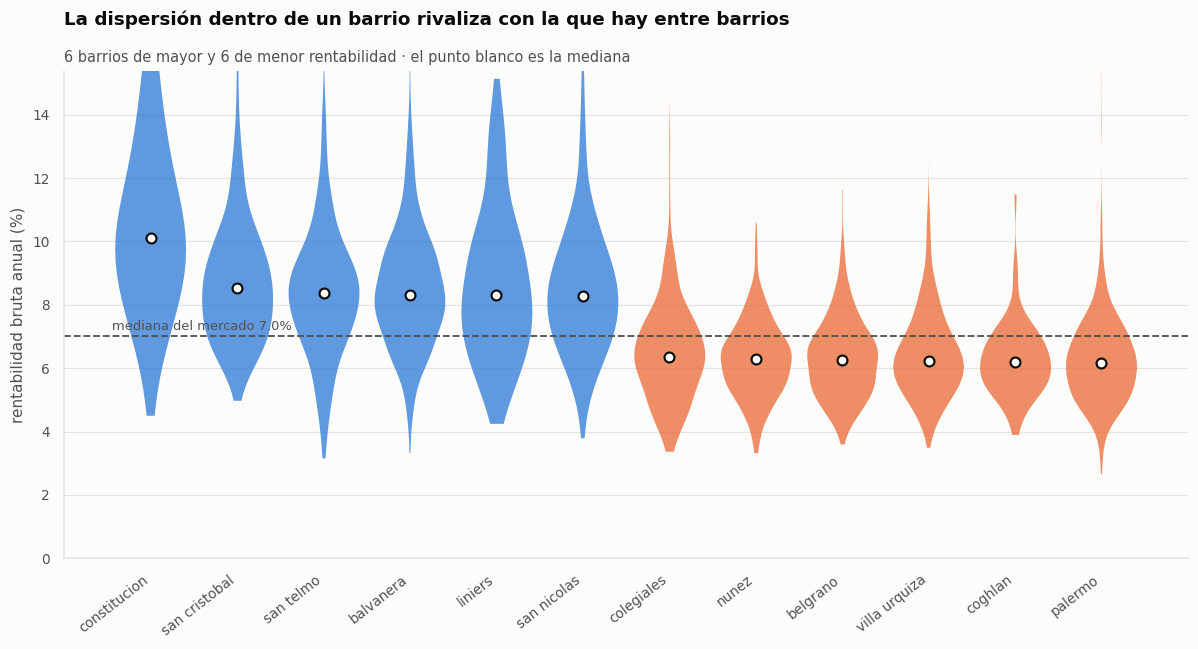

Eje recortado en 15.4%: quedan fuera 21 de 4,139 propiedades (0.51%). Se recorta la vista, no los datos.


In [47]:
# 12 barrios: los 6 que mas rinden y los 6 que menos, para que el contraste
# sea legible. Con los 29 el eje se vuelve ilegible y no se gana nada.
N = S.N_BARRIOS_EXTREMOS
sel = pd.concat([barrios.head(N), barrios.tail(N)])
datos = [ok.loc[ok.barrio == b, "rent_bruta_pct"].values for b in sel.index]

fig, ax = plt.subplots(figsize=(11, 6))
vp = ax.violinplot(datos, positions=range(len(sel)), showextrema=False, widths=0.82)
for i, cuerpo in enumerate(vp["bodies"]):
    # El eje ya separa los dos grupos: el color refuerza, no carga la unica pista.
    cuerpo.set_facecolor(eda.SERIE_1 if i < N else eda.SERIE_2)
    cuerpo.set_alpha(0.75)
ax.scatter(range(len(sel)), sel.mediana, color=eda.SUPERFICIE, s=42, zorder=3,
           edgecolor=eda.TINTA, linewidth=1.4)

med_global = ok.rent_bruta_pct.median()
ax.axhline(med_global, color=eda.TINTA_2, linestyle="--", linewidth=1.2)
# La cola derecha aplasta los violines contra el piso: se recorta la VISTA al
# cuantil de supuestos.py. Los estadisticos se calculan sobre la serie completa.
techo = max(ok.loc[ok.barrio.isin(sel.index), "rent_bruta_pct"].quantile(S.VIOLIN_TECHO_CUANTIL),
            sel.p75.max() + 1)
ax.set_ylim(0, techo)
ax.text(-0.45, med_global + techo * 0.012, f"mediana del mercado {med_global:.1f}%",
        ha="left", fontsize=8.5, color=eda.TINTA_2)
recortados = int((ok.loc[ok.barrio.isin(sel.index), "rent_bruta_pct"] > techo).sum())

ax.set_xticks(range(len(sel)))
ax.set_xticklabels(sel.index, rotation=38, ha="right", fontsize=9)
ax.set_ylabel("rentabilidad bruta anual (%)")
eda.titulo(ax, "La dispersión dentro de un barrio rivaliza con la que hay entre barrios",
           f"{N} barrios de mayor y {N} de menor rentabilidad · el punto blanco es la mediana")
fig.tight_layout()
eda.guardar(fig, 5, "violin_rentabilidad_barrio")
plt.show()

n_sel = int(ok.barrio.isin(sel.index).sum())
print(f"Eje recortado en {techo:.1f}%: quedan fuera {recortados} de {n_sel:,} propiedades "
      f"({recortados / n_sel * 100:.2f}%). Se recorta la vista, no los datos.")

**Control: ¿la dispersión dentro del barrio es solo mezcla de tamaños?** Un barrio con
monoambientes y departamentos grandes tiene un IQR ancho aunque cada tamaño, por
separado, rinda parejo. Se repite la comparación **dentro de cada rango de superficie**:
la dispersión dentro de una celda barrio × superficie contra la distancia entre barrios
del mismo tamaño.

In [48]:
filas = []
for tramo in S.ORDEN_SUPERFICIE_RANGO:
    sub = ok[ok.superficie_rango == tramo]
    celdas = sub.groupby("barrio").rent_bruta_pct
    n = celdas.size()
    validos = n[n >= S.MIN_VENTAS_BARRIO].index
    if len(validos) < 2:
        continue
    g = sub[sub.barrio.isin(validos)].groupby("barrio").rent_bruta_pct
    iqr = g.quantile(.75) - g.quantile(.25)
    filas.append({"tramo": tramo, "barrios": len(validos),
                  "entre_barrios_pp": g.median().max() - g.median().min(),
                  "iqr_intra_mediano_pp": iqr.median(), "iqr_intra_max_pp": iqr.max()})
control = pd.DataFrame(filas).set_index("tramo").round(2)
control["intra_max / entre"] = (control.iqr_intra_max_pp / control.entre_barrios_pp).round(2)
print(f"Dentro de cada rango de superficie (celdas de {S.MIN_VENTAS_BARRIO}+ ventas):")
print(control.to_string())

Dentro de cada rango de superficie (celdas de 30+ ventas):
          barrios  entre_barrios_pp  iqr_intra_mediano_pp  iqr_intra_max_pp  intra_max / entre
tramo                                                                                         
hasta 35       13              1.92                  1.48              1.85               0.96
36-55          25              3.76                  1.83              2.73               0.73
56-80          23              2.85                  1.74              3.66               1.28
81-120         18              2.74                  1.95              4.48               1.64
120+           22              5.48                  3.13              6.32               1.15


> **Lectura.** Los violines son anchos: dentro de un barrio conviven propiedades que
> rinden como las del tope del ranking y otras que rinden como las del fondo. El control
> por tamaño muestra que **no es mezcla de tamaños**: aun comparando unidades del mismo
> rango de superficie, la dispersión interna de un barrio sigue siendo del orden de la
> distancia entre barrios.
>
> Para el cliente esto reordena la decisión. Elegir el barrio correcto y después comprar
> cualquier cosa dentro de él no alcanza: **la propiedad puntual pesa tanto como la
> ubicación**. Por eso este trabajo estima la rentabilidad unidad por unidad en vez de
> publicar solo un ranking de barrios.
>
> Advertencia: la dispersión observada incluye tanto diferencias reales entre
> propiedades como el error de la estimación de alquiler. La sección 3.1 separa las dos
> cosas.

### Gráfico 06 — Precio del metro cuadrado contra rentabilidad (H1)

> **Pregunta.** La primera hipótesis del trabajo afirma que **la rentabilidad bruta es
> inversamente proporcional al precio del m² del barrio**: los barrios premium rinden menos
> como renta. ¿Se sostiene sobre estos datos, y se sostiene comparando unidades del mismo
> tamaño?

In [49]:
b = eda.por_barrio(ok, "rent_bruta_pct", minimo=S.MIN_VENTAS_BARRIO).copy()
b["venta_m2"] = ok.groupby("barrio").venta_m2_usd.median().reindex(b.index)

rho = b.venta_m2.corr(b.mediana, method="spearman")
rho_pearson = b.venta_m2.corr(b.mediana, method="pearson")
print(f"Barrios analizados          : {len(b)}  ({S.MIN_VENTAS_BARRIO} o mas ventas cada uno)")
print(f"Spearman precio/m2 vs renta : {rho:+.4f}")
print(f"Pearson  (de referencia)    : {rho_pearson:+.4f}")

Barrios analizados          : 29  (30 o mas ventas cada uno)
Spearman precio/m2 vs renta : -0.9026
Pearson  (de referencia)    : -0.9270


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/06_scatter_precio_rentabilidad.png


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

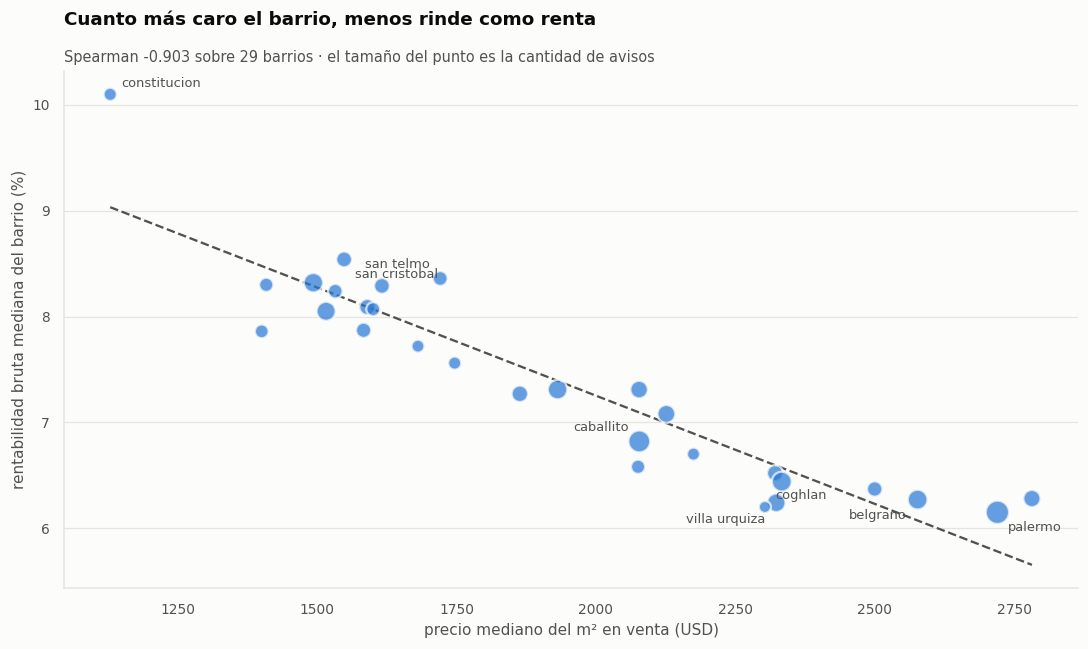

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(b.venta_m2, b.mediana, s=np.sqrt(b.n) * 7, color=eda.SERIE_1,
           alpha=0.72, edgecolor=eda.SUPERFICIE, linewidth=1.5, zorder=3)
orden = np.argsort(b.venta_m2.values)
x, y = b.venta_m2.values[orden], b.mediana.values[orden]
coef = np.polyfit(x, y, 1)
ax.plot(x, np.polyval(coef, x), color=eda.TINTA_2, linewidth=1.5, linestyle="--", zorder=2)

# Solo extremos y conocidos: una etiqueta por punto es una sopa de letras.
destacar = list(b.head(3).index) + list(b.tail(3).index) + \
           [x for x in ["palermo", "caballito", "belgrano"] if x in b.index]
OFFSETS = [(7, 5), (7, -12), (-7, 7), (-7, -13)]
for i, barrio in enumerate(dict.fromkeys(destacar)):
    r = b.loc[barrio]
    dx, dy = OFFSETS[i % len(OFFSETS)]
    ax.annotate(barrio, (r.venta_m2, r.mediana), fontsize=8.5, color=eda.TINTA_2,
                xytext=(dx, dy), textcoords="offset points", ha="left" if dx > 0 else "right")
ax.set_xlabel("precio mediano del m² en venta (USD)")
ax.set_ylabel("rentabilidad bruta mediana del barrio (%)")
eda.titulo(ax, "Cuanto más caro el barrio, menos rinde como renta",
           f"Spearman {rho:+.3f} sobre {len(b)} barrios · el tamaño del punto es la cantidad de avisos")
fig.tight_layout()
eda.guardar(fig, 6, "scatter_precio_rentabilidad")
plt.show()

In [51]:
# Control por tamanio: el mismo Spearman, calculado entre barrios DENTRO de
# cada rango de superficie. Si H1 fuera un efecto de que los barrios caros
# tienen unidades mas grandes, aca se desarmaria.
filas = []
for tramo in S.ORDEN_SUPERFICIE_RANGO:
    sub = ok[ok.superficie_rango == tramo]
    g = sub.groupby("barrio").agg(n=("rent_bruta_pct", "size"),
                                  m2=("venta_m2_usd", "median"),
                                  renta=("rent_bruta_pct", "median"))
    g = g[g.n >= S.MIN_AVISOS_CELDA]
    if len(g) >= 5:
        filas.append({"tramo": tramo, "barrios": len(g),
                      "spearman": g.m2.corr(g.renta, method="spearman")})
h1_tramos = pd.DataFrame(filas).set_index("tramo").round(3)
print(f"Spearman precio/m2 vs renta entre barrios, dentro de cada tramo "
      f"(celdas de {S.MIN_AVISOS_CELDA}+):")
print(h1_tramos.to_string())
print()
print(f"Rango de los coeficientes por tramo: {h1_tramos.spearman.min():+.3f} a "
      f"{h1_tramos.spearman.max():+.3f}  (todos los barrios juntos: {rho:+.3f})")

Spearman precio/m2 vs renta entre barrios, dentro de cada tramo (celdas de 10+):
          barrios  spearman
tramo                      
hasta 35       25    -0.876
36-55          29    -0.924
56-80          29    -0.942
81-120         28    -0.940
120+           29    -0.949

Rango de los coeficientes por tramo: -0.949 a -0.876  (todos los barrios juntos: -0.903)


> **Lectura.** La nube cae de forma nítida y monótona, y el control por tamaño la
> sostiene: comparando solo unidades del mismo rango de superficie, la relación entre
> precio del m² y renta sigue siendo negativa y fuerte en cada tramo. **H1 queda
> respaldada** y no es un efecto de que los barrios caros tengan unidades más grandes.
>
> La razón económica es que el precio de venta y el alquiler no se mueven juntos. El precio
> incorpora expectativas de revalorización, seguridad, prestigio y liquidez; el alquiler
> responde sobre todo a la capacidad de pago del inquilino de la zona.
>
> **La advertencia importa tanto como el hallazgo.** Mayor rentabilidad no equivale a mejor
> inversión: este KPI mide renta, no retorno total, y el dataset (un corte temporal único)
> no permite estimar revalorización.

### Gráfico 07 — ¿Cuánto se parece la cartera de RE/MAX al mercado?

> 
> **Pregunta.** Todo el análisis sale de una sola red inmobiliaria. **¿Sus precios y su
> distribución por zonas se parecen a los del mercado, o el trabajo está describiendo un
> segmento?** Se compara contra dos fuentes oficiales: el precio publicado del m² que
> calcula el Instituto de Estadística de la Ciudad sobre avisos de Argenprop, en la misma
> celda barrio × ambientes × estado, y el stock de departamentos del Censo 2022 por comuna.
>

In [53]:
sp = pd.read_csv("../data/processed/sesgo_precio_barrio.csv", encoding="utf-8-sig")
sr = pd.read_csv("../data/processed/sesgo_representacion_comuna.csv", encoding="utf-8-sig")

print(f"Celdas barrio x ambientes x estado comparadas: {len(sp)}")
print(f"    RE/MAX publica mas barato en {int((sp.desvio_pct < 0).sum())} "
      f"({(sp.desvio_pct < 0).mean() * 100:.0f}%)")
print(f"    desvio mediano: {sp.desvio_pct.median():+.1f}%   "
      f"promedio ponderado por avisos: {np.average(sp.desvio_pct, weights=sp.n_remax):+.1f}%")
for est, g in sp.groupby("estado"):
    print(f"    {est:<9}: desvio mediano {g.desvio_pct.median():+.1f}% en {len(g)} celdas")
print()
dist = (sr.pct_cartera_venta - sr.pct_departamentos_ciudad).abs().sum() / 2
print(f"Representacion: habria que reasignar el {dist:.1f}% de las ventas para replicar el censo")
print(f"    comunas sobrerrepresentadas (indice > 1,25): {sr.loc[sr.indice_venta > 1.25, 'comuna'].tolist()}")
print(f"    comunas subrepresentadas (indice < 0,75)   : {sr.loc[sr.indice_venta < 0.75, 'comuna'].tolist()}")

Celdas barrio x ambientes x estado comparadas: 135
    RE/MAX publica mas barato en 127 (94%)
    desvio mediano: -9.6%   promedio ponderado por avisos: -8.0%
    estrenar : desvio mediano -17.2% en 28 celdas
    usado    : desvio mediano -9.0% en 107 celdas

Representacion: habria que reasignar el 7.2% de las ventas para replicar el censo
    comunas sobrerrepresentadas (indice > 1,25): [1]
    comunas subrepresentadas (indice < 0,75)   : [4, 8, 9]


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/07_sesgo_remax.png


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

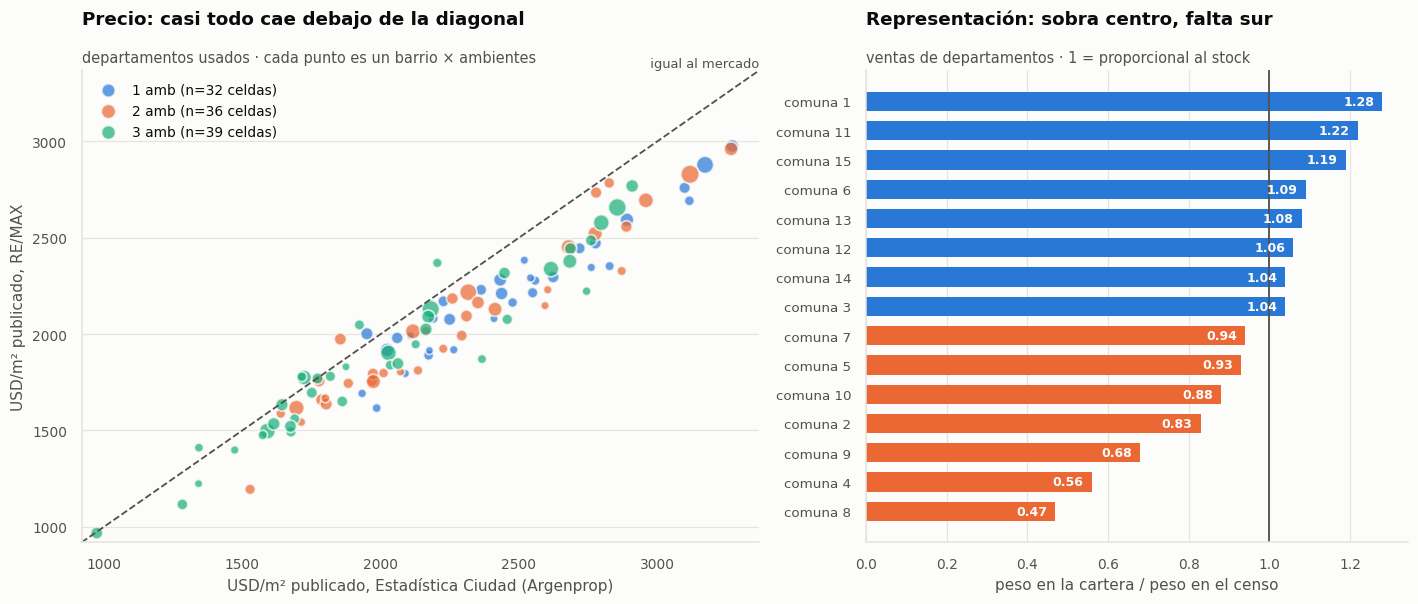

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw={"width_ratios": [1.25, 1]})

# Panel 1: precio. Una serie por cantidad de ambientes (tres slots, los
# certificados). Solo usados: es el grueso de la cartera y del mercado.
u = sp[sp.estado == "usado"]
for amb, color in zip([1, 2, 3], eda.CATEGORICA):
    g = u[u.ambientes == amb]
    ax1.scatter(g.idecba_media, g.remax_media, s=np.sqrt(g.n_remax) * 9, color=color,
                alpha=0.72, edgecolor=eda.SUPERFICIE, linewidth=1.2,
                label=f"{amb} amb (n={len(g)} celdas)")
lim = [min(u.idecba_media.min(), u.remax_media.min()) * 0.95,
       max(u.idecba_media.max(), u.remax_media.max()) * 1.03]
ax1.plot(lim, lim, color=eda.TINTA_2, linestyle="--", linewidth=1.2)
ax1.text(lim[1], lim[1], "  igual al mercado", fontsize=8.5, color=eda.TINTA_2, va="bottom", ha="right")
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("USD/m² publicado, Estadística Ciudad (Argenprop)")
ax1.set_ylabel("USD/m² publicado, RE/MAX")
ax1.legend(loc="upper left")
eda.titulo(ax1, "Precio: casi todo cae debajo de la diagonal",
           "departamentos usados · cada punto es un barrio × ambientes")

# Panel 2: representacion por comuna.
r = sr.sort_values("indice_venta")
colores = [eda.SERIE_2 if v < 1 else eda.SERIE_1 for v in r.indice_venta]
ax2.barh(range(len(r)), r.indice_venta, color=colores, height=0.66)
ax2.axvline(1, color=eda.TINTA_2, linewidth=1.2)
ax2.set_yticks(range(len(r)))
ax2.set_yticklabels([f"comuna {c}" for c in r.comuna], fontsize=8.8)
# Etiquetas adentro de la barra: afuera chocan con la linea de referencia en 1.
for i, v in enumerate(r.indice_venta):
    ax2.text(v - 0.02, i, f"{v:.2f}", va="center", ha="right", fontsize=8.2,
             color=eda.SUPERFICIE, fontweight="600")
ax2.set_xlabel("peso en la cartera / peso en el censo")
eda.sin_grilla_y(ax2)
eda.titulo(ax2, "Representación: sobra centro, falta sur",
           "ventas de departamentos · 1 = proporcional al stock")
fig.tight_layout()
eda.guardar(fig, 7, "sesgo_remax")
plt.show()

> **Lectura.** Casi todos los puntos del panel izquierdo caen **debajo de la diagonal**: en
> la misma celda de barrio, ambientes y estado, la cartera de RE/MAX publica más barato
> que el promedio de Argenprop. El desfase de un trimestre entre las fuentes no lo explica
> (ver `data/processed/reporte_sesgo.txt`).
>
> La consecuencia va directo al KPI: **el precio está en el denominador de la
> rentabilidad**, así que la de la cartera sale más alta que la que daría el precio
> publicado promedio del mercado. El alquiler estimado también sale de avisos de RE/MAX, y
> no hay fuente oficial para saber si su cartera de alquileres tiene el mismo sesgo. El
> efecto neto no se puede firmar, pero los niveles absolutos de rentabilidad deben leerse
> como los de este segmento y no como los de CABA.
>
> El panel derecho agrega la segunda advertencia: la cartera pesa de más en el centro y de
> menos en el sur. Los promedios de ciudad del trabajo heredan esa composición, y por eso
> los KPIs se leen por barrio. El índice mide composición contra el stock censado, no
> contra la oferta, que no tiene una fuente pública por zona.

## Bloque B — ¿Le gana el ladrillo a la alternativa?

### Gráfico 08 — Rentabilidad del ladrillo contra la renta fija y el alquiler temporal

> **Pregunta.** Es la pregunta que decide si el resto del análisis importa. El cliente
> tiene dólares y puede comprar un departamento o no comprarlo. **¿La renta que da el
> ladrillo supera lo que rinde el mismo capital en una obligación negociable corporativa
> en dólares, que no tiene vacancia, ni gastos, ni costo de salida? ¿Y la supera si en vez
> de alquilar con contrato se alquila por noche?**
>
> La banda de retorno mínimo es la de `supuestos.py` (ON de YPF 2031 y Pampa 2037). Es una
> **restricción del análisis, no una recomendación de inversión**.

In [55]:
tv = pd.read_csv("../data/processed/temporal_vs_tradicional.csv", encoding="utf-8-sig")
piso, techo_on = S.RETORNO_MINIMO_BANDA
alc = ok[ok.venta_usd.between(*S.PRESUPUESTO_USD)]

def linea(nombre, serie):
    print(f"{nombre:<46}{serie.median():>7.2f}%{(serie >= piso).mean() * 100:>9.1f}%"
          f"{(serie >= techo_on).mean() * 100:>9.1f}%   n={len(serie):,}")

print(f"Banda de retorno minimo: {piso:.2f}% a {techo_on:.2f}%   "
      f"(referencia soberana {S.RETORNO_SOBERANO_REF_PCT:.2f}%)")
print()
print(f"{'':<46}{'mediana':>8}{'>= piso':>10}{'>= techo':>9}")
linea("Ladrillo, rentabilidad bruta", ok.rent_bruta_pct)
linea("Ladrillo, rentabilidad neta", ok.rent_neta_pct)
linea("Ladrillo neta, dentro del presupuesto", alc.rent_neta_pct)
# El extremo optimista de la banda de incertidumbre (KPI 4), con los mismos
# descuentos que el KPI 2: si ni asi pasa el piso, no es un tema de error.
factor = (1 - S.VACANCIA_PCT / 100) * (1 - S.GASTOS_PCT / 100)
linea("Ladrillo neta, extremo optimista de la banda", ok.rent_bruta_max * factor)
linea("Temporal neta, ocupacion Inside Airbnb (celdas)", tv.temp_neta_pct)
linea(f"Temporal neta, ocupacion {S.OCUPACION_REF_PCT:.0f}% (celdas)", tv.temp_neta_ref_pct)

Banda de retorno minimo: 7.10% a 7.60%   (referencia soberana 11.65%)

                                               mediana   >= piso >= techo
Ladrillo, rentabilidad bruta                     7.01%     48.1%     37.2%   n=9,203
Ladrillo, rentabilidad neta                      5.67%     19.1%     13.6%   n=9,203
Ladrillo neta, dentro del presupuesto            5.56%     14.6%     10.0%   n=5,198
Ladrillo neta, extremo optimista de la banda     6.40%     33.8%     25.0%   n=9,203
Temporal neta, ocupacion Inside Airbnb (celdas)  -0.61%      0.0%      0.0%   n=47
Temporal neta, ocupacion 53% (celdas)            3.86%      4.3%      0.0%   n=47


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/08_ladrillo_vs_alternativas.png


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.


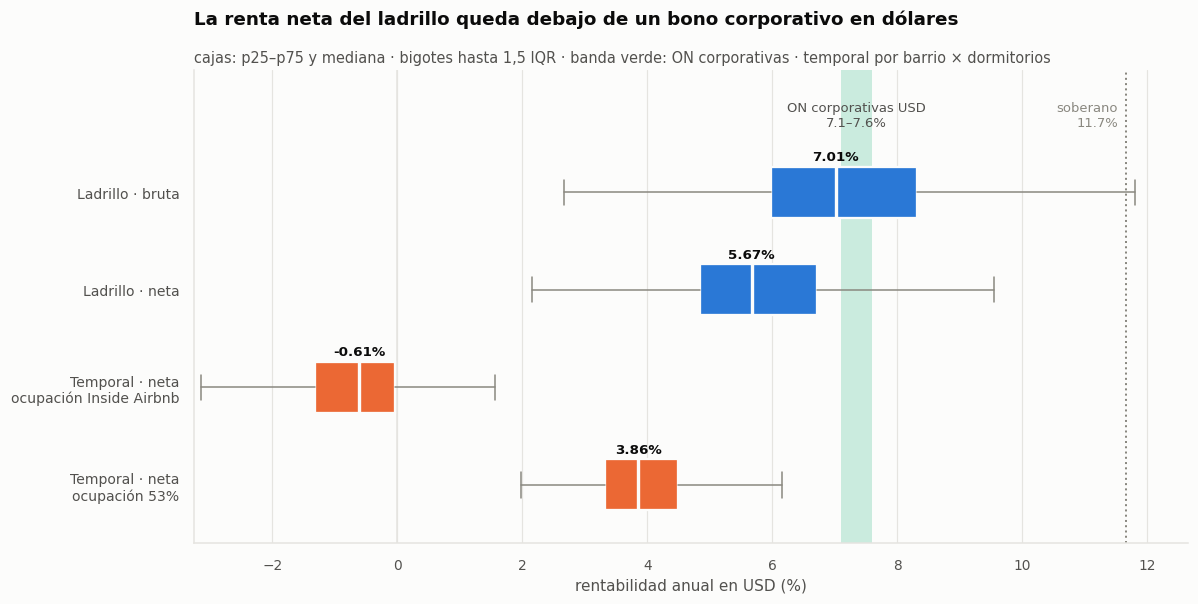

In [56]:
filas = [("Ladrillo · bruta", ok.rent_bruta_pct, eda.SERIE_1),
         ("Ladrillo · neta", ok.rent_neta_pct, eda.SERIE_1),
         ("Temporal · neta\nocupación Inside Airbnb", tv.temp_neta_pct, eda.SERIE_2),
         (f"Temporal · neta\nocupación {S.OCUPACION_REF_PCT:.0f}%", tv.temp_neta_ref_pct, eda.SERIE_2)]

fig, ax = plt.subplots(figsize=(11, 5.6))
ax.axvspan(piso, techo_on, color=eda.SERIE_3, alpha=0.22, zorder=0)
ax.axvline(S.RETORNO_SOBERANO_REF_PCT, color=eda.TINTA_3, linestyle=":", linewidth=1.3)
ax.axvline(0, color=eda.GRILLA, linewidth=1)

pos = list(range(len(filas)))[::-1]
bp = ax.boxplot([f[1].values for f in filas], positions=pos, vert=False, widths=0.52,
                patch_artist=True, showfliers=False,
                medianprops=dict(color=eda.SUPERFICIE, linewidth=2.2),
                whiskerprops=dict(color=eda.TINTA_3), capprops=dict(color=eda.TINTA_3),
                boxprops=dict(edgecolor=eda.SUPERFICIE, linewidth=1.5))
# Cajas opacas y por encima de la banda: con transparencia la banda se veia
# atravesando la caja y parecia parte del dato.
for caja, f in zip(bp["boxes"], filas):
    caja.set_facecolor(f[2]); caja.set_zorder(3)
for parte in ("medians", "whiskers", "caps"):
    for linea_ in bp[parte]:
        linea_.set_zorder(4)
for p, f in zip(pos, filas):
    ax.text(f[1].median(), p + 0.33, f"{f[1].median():.2f}%", ha="center",
            fontsize=8.8, color=eda.TINTA, fontweight="600")

ax.set_yticks(pos)
ax.set_yticklabels([f[0] for f in filas], fontsize=9.2)
ymax = len(filas) - 0.35
ax.text((piso + techo_on) / 2, ymax, f"ON corporativas USD\n{piso:.1f}–{techo_on:.1f}%",
        ha="center", va="bottom", fontsize=8.6, color=eda.TINTA_2)
ax.text(S.RETORNO_SOBERANO_REF_PCT - 0.12, ymax, f"soberano\n{S.RETORNO_SOBERANO_REF_PCT:.1f}%",
        ha="right", va="bottom", fontsize=8.6, color=eda.TINTA_3)
ax.set_ylim(-0.6, len(filas) + 0.25)
hi = max(np.percentile(f[1], 95) for f in filas)
ax.set_xlim(min(-1, min(np.percentile(f[1], 5) for f in filas) - 0.5), max(hi, S.RETORNO_SOBERANO_REF_PCT) + 1)
ax.set_xlabel("rentabilidad anual en USD (%)")
eda.sin_grilla_y(ax)
eda.titulo(ax, "La renta neta del ladrillo queda debajo de un bono corporativo en dólares",
           "cajas: p25–p75 y mediana · bigotes hasta 1,5 IQR · banda verde: ON corporativas · temporal por barrio × dormitorios")
fig.tight_layout()
eda.guardar(fig, 8, "ladrillo_vs_alternativas")
plt.show()

> **Lectura.** Es el hallazgo que cambia el rumbo del negocio. La rentabilidad **bruta** del
> ladrillo está en la zona de la banda; la **neta**, que es la que cobra el inversor
> después de vacancia y gastos, queda por **debajo del piso** para la mayoría de las
> propiedades. Y eso comparando contra un instrumento que paga en dólares, se vende en un
> día, no tiene inquilino que falte ni expensas extraordinarias. La tabla de arriba muestra
> que el resultado no cambia al restringirse al presupuesto del cliente ni al tomar el
> extremo optimista de la banda de incertidumbre de cada propiedad.
>
> El alquiler temporal no rescata el caso. Con la ocupación que estima Inside Airbnb su
> neta es negativa en la mayoría de los barrios; aun con la ocupación que informa la
> prensa, casi nunca le gana al tradicional (el detalle está en `temporal.py` y en P3 del
> README).
>
> Qué **no** dice el gráfico: que comprar sea un error. El KPI mide renta corriente y deja
> afuera la apreciación del inmueble, que es la otra fuente de retorno del ladrillo y que
> un corte temporal único no permite estimar. Lo que sí dice es que **solo por renta, la
> propiedad típica no le gana a un bono corporativo**, así que la decisión depende de la
> minoría que sí lo hace, o de una apuesta explícita a la revalorización. Eso es lo que la
> función de decisión de la 3ra entrega tiene que resolver.

### 3.1 ¿Cuánta confianza le doy a cada número?

Todas las rentabilidades son **estimadas**: salen de un modelo que predice cuánto se
alquilaría una propiedad que hoy está en venta. El KPI 4 le da a cada una su banda de
error, que depende del tramo de superficie.

In [57]:
seg = pd.cut(ok.sup_total_m2, M.BINS_SUP, labels=M.LAB_SUP)
tabla_err = ok.assign(segmento=seg, banda=ok.rent_bruta_max - ok.rent_bruta_min) \
    .groupby("segmento", observed=True).agg(
        n=("rent_bruta_pct", "size"),
        rent_mediana=("rent_bruta_pct", "median"),
        error_pct=("error_estimacion", lambda s: s.median() * 100),
        banda_pp=("banda", "median"))
print(tabla_err.round(2).to_string())
print()
med = ok.rent_bruta_pct.median()
solapan = ((ok.rent_bruta_min <= med) & (ok.rent_bruta_max >= med)).mean() * 100
print(f"Propiedades cuya banda contiene la mediana del mercado ({med:.2f}%): {solapan:.1f}%")

             n  rent_mediana  error_pct  banda_pp
segmento                                         
<35       1031          7.20      10.43      1.50
35-50     2018          6.95       9.71      1.34
50-70     2046          6.74      12.34      1.66
70-100    1816          6.81      15.41      2.10
100+      2292          7.44      17.38      2.58

Propiedades cuya banda contiene la mediana del mercado (7.01%): 41.7%


> **Lectura.** El error crece con la superficie, porque hay pocos alquileres publicados de
> unidades grandes. Para las propiedades cuya banda contiene la mediana del mercado, decir
> "esta rinde más que el promedio" no está respaldado por la precisión del modelo. Para
> alguien que compra una sola unidad, esa distinción pesa tanto como el rendimiento: dos
> departamentos con rentabilidades estimadas parecidas y bandas que se superponen son,
> para esta herramienta, el mismo departamento.

## Bloque C — ¿Qué atributos mueven la renta, comparando semejantes?

### Gráfico 09 — El efecto de los amenities, medido dentro del estrato

> **Pregunta.** Los amenities (pileta, gimnasio, SUM, seguridad) son el argumento de venta
> más visible de un aviso y el cliente paga una prima por ellos. **¿Esa prima se recupera
> en el alquiler?** La comparación directa entre propiedades con y sin amenities es
> engañosa: los edificios con amenities se concentran en barrios caros y en unidades de
> otro tamaño. Por eso la diferencia se mide **dentro de cada celda barrio × superficie**,
> y después se agrega.

In [58]:
ingenua = (ok.loc[ok.amenities == 1, "rent_bruta_pct"].median()
           - ok.loc[ok.amenities == 0, "rent_bruta_pct"].median())

def estimar(respuesta, estrato, base=ok):
    t = eda.efecto_estratificado(base, "amenities", respuesta, estrato, S.MIN_GRUPO_ESTRATO)
    return t, eda.resumir_efecto(t, len(base))

t_am, r_am = estimar("rent_bruta_pct", ESTRATO)
t_amt, r_amt = estimar("rent_bruta_pct", ESTRATO_T)

print(f"Diferencia de rentabilidad bruta, con amenities menos sin amenities (pp):")
print(f"    ingenua (todo el mercado)            : {ingenua:+.2f}")
for nombre, r in [("barrio x superficie", r_am), ("barrio x superficie x tipo", r_amt)]:
    print(f"    dentro de {nombre:<27}: {r['mediana_ponderada']:+.2f}   "
          f"(p25 {r['p25']:+.2f}, p75 {r['p75']:+.2f}; {r['celdas']} celdas, "
          f"{r['pct_celdas_negativas']:.0f}% negativas, cubre {r['pct_filas_cubiertas']:.1f}%)")
print()
# El mecanismo: si la renta baja, es porque el precio sube mas que el alquiler.
for resp, etq in [("venta_m2_usd", "precio del m2 (USD)"),
                  ("alquiler_est_m2", "alquiler estimado por m2 (USD/mes)")]:
    t, r = estimar(resp, ESTRATO)
    rel = eda.mediana_ponderada(t.diferencia / t.mediana_0 * 100, t.peso)
    print(f"Prima de los amenities en el {etq:<36}: {rel:+.1f}% dentro del estrato")

Diferencia de rentabilidad bruta, con amenities menos sin amenities (pp):
    ingenua (todo el mercado)            : -0.49
    dentro de barrio x superficie        : -0.55   (p25 -0.79, p75 +0.06; 122 celdas, 74% negativas, cubre 94.8%)
    dentro de barrio x superficie x tipo : -0.64   (p25 -0.89, p75 +0.14; 136 celdas, 71% negativas, cubre 70.1%)

Prima de los amenities en el precio del m2 (USD)                 : +23.5% dentro del estrato
Prima de los amenities en el alquiler estimado por m2 (USD/mes)  : +13.0% dentro del estrato


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.


Desvio respecto de la mediana de la celda (pp): con amenities -0.23 (n=3,751), sin amenities +0.12 (n=5,395)


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/09_amenities_dentro_del_estrato.png


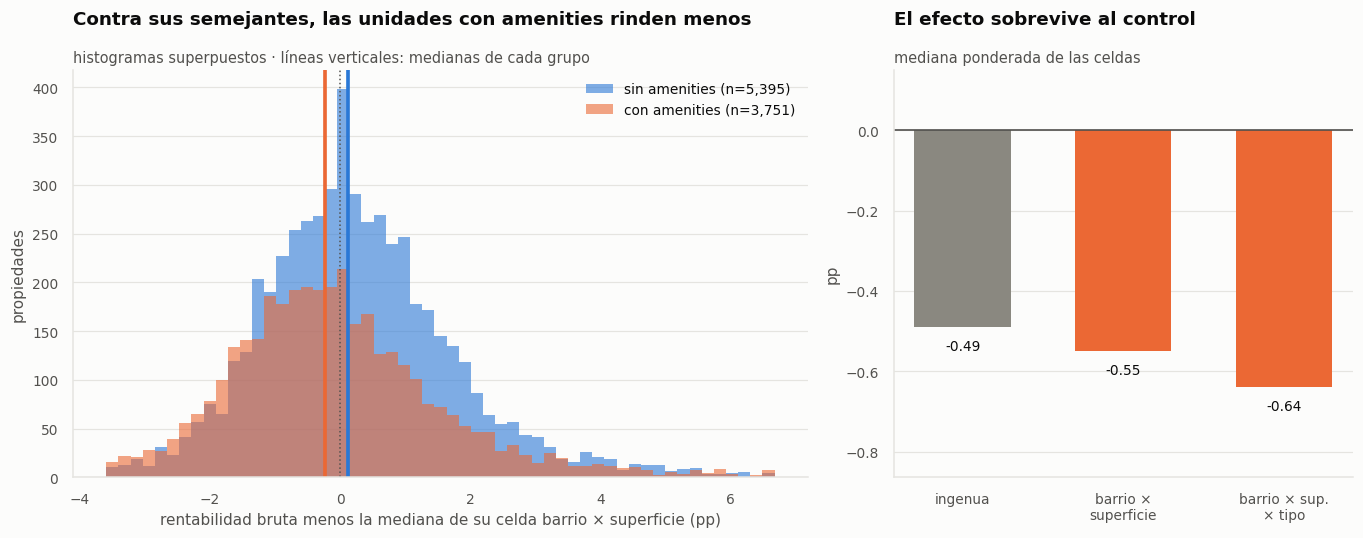

In [59]:
# Histogramas superpuestos, pero del desvio de cada propiedad respecto de la
# mediana de SU celda barrio x superficie: asi los dos grupos se comparan
# contra propiedades semejantes y no contra todo el mercado. Superponer la
# rentabilidad cruda mostraria diferencia de barrio, no de amenities.
n_c = ok.groupby(ESTRATO, observed=True).rent_bruta_pct.transform("size")
base_h = ok[n_c >= S.MIN_AVISOS_CELDA].copy()
base_h["desvio_celda"] = (base_h.rent_bruta_pct
                          - base_h.groupby(ESTRATO, observed=True).rent_bruta_pct.transform("median"))
con_h = base_h.loc[base_h.amenities == 1, "desvio_celda"]
sin_h = base_h.loc[base_h.amenities == 0, "desvio_celda"]
print(f"Desvio respecto de la mediana de la celda (pp): "
      f"con amenities {con_h.median():+.2f} (n={len(con_h):,}), "
      f"sin amenities {sin_h.median():+.2f} (n={len(sin_h):,})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5), gridspec_kw={"width_ratios": [1.6, 1]})
q_min, q_max = S.HIST_RANGO_CUANTILES
bins = np.linspace(base_h.desvio_celda.quantile(q_min), base_h.desvio_celda.quantile(q_max),
                   S.HIST_N_BORDES)
ax1.hist(sin_h, bins=bins, color=eda.SERIE_1, alpha=0.6, label=f"sin amenities (n={len(sin_h):,})")
ax1.hist(con_h, bins=bins, color=eda.SERIE_2, alpha=0.6, label=f"con amenities (n={len(con_h):,})")
for serie, color in [(sin_h, eda.SERIE_1), (con_h, eda.SERIE_2)]:
    ax1.axvline(serie.median(), color=color, linewidth=2.4)
ax1.axvline(0, color=eda.TINTA_2, linewidth=1, linestyle=":")
ax1.legend(loc="upper right")
ax1.set_xlabel("rentabilidad bruta menos la mediana de su celda barrio × superficie (pp)")
ax1.set_ylabel("propiedades")
eda.titulo(ax1, "Contra sus semejantes, las unidades con amenities rinden menos",
           "histogramas superpuestos · líneas verticales: medianas de cada grupo")

est = pd.Series({"ingenua": ingenua, "barrio ×\nsuperficie": r_am["mediana_ponderada"],
                 "barrio × sup.\n× tipo": r_amt["mediana_ponderada"]})
ax2.bar(range(len(est)), est.values, color=[eda.TINTA_3, eda.SERIE_2, eda.SERIE_2], width=0.6)
ax2.axhline(0, color=eda.TINTA_2, linewidth=1.1)
for i, v in enumerate(est.values):
    ax2.text(i, v - 0.03, f"{v:+.2f}", ha="center", va="top", fontsize=9, color=eda.TINTA)
ax2.set_xticks(range(len(est)))
ax2.set_xticklabels(est.index, fontsize=9)
ax2.set_ylabel("pp")
ax2.set_ylim(min(est.min() * 1.35, -0.1), 0.15)
eda.titulo(ax2, "El efecto sobrevive al control", "mediana ponderada de las celdas")
fig.tight_layout()
eda.guardar(fig, 9, "amenities_dentro_del_estrato")
plt.show()

> **Lectura.** La comparación ingenua ya mostraba que las propiedades con amenities rinden
> menos, pero podía ser barrio: los edificios con pileta están en las zonas caras, que
> rinden menos por otras razones (H1). **Dentro de cada celda barrio × superficie el efecto
> no desaparece**: en la mayoría de las celdas, la unidad con amenities rinde menos que la
> comparable sin ellos, y el resultado se sostiene al fijar también el tipo de propiedad.
>
> El mecanismo lo muestran las dos primas calculadas arriba: dentro del mismo estrato, los
> amenities **encarecen el metro cuadrado más de lo que suben el alquiler**. El inquilino no
> paga la prima completa, y la diferencia la absorbe el propietario como menor renta.
>
> Para el cliente: comprar con amenities no es un error, pero es una decisión que se paga
> en renta. Si los quiere, que sea por gusto propio o por liquidez de reventa, no porque
> crea que mejoran el retorno.

### Gráfico 10 — Qué se mueve junto con la rentabilidad

> **Pregunta.** Con decenas de variables dicotómicas y continuas, **¿cuáles se mueven
> junto con la rentabilidad, y cuáles entre sí?** Dos variables muy correlacionadas entre sí
> aportan una sola cosa, no dos. Y cada correlación con la renta se contrasta con la misma
> correlación medida dentro del estrato.

In [60]:
VARS = ["rent_bruta_pct", "venta_usd", "venta_m2_usd", "sup_total_m2",
        "ambientes", "banos", "antiguedad_anios", "expensas_usd",
        "n_amenities", "amenities", "cochera_txt", "balcon", "terraza",
        "ascensor", "seguridad", "a_reciclar", "es_planta_baja"]
corr = eda.matriz_correlacion(ok, VARS, metodo="spearman")

# La misma correlacion con la renta, dentro de cada celda del estrato con
# suficientes avisos para que un Spearman no oscile de mas.
n_celda = ok.groupby(ESTRATO, observed=True).rent_bruta_pct.transform("size")
base_c = ok[n_celda >= S.MIN_CELDA_CORRELACION]
dentro = {}
for v in VARS[1:]:
    rs = [g[v].corr(g.rent_bruta_pct, method="spearman")
          for _, g in base_c.groupby(ESTRATO, observed=True) if g[v].nunique() > 1]
    dentro[v] = np.nanmedian(rs) if rs else np.nan
comp = pd.DataFrame({"global": corr["rent_bruta_pct"].drop("rent_bruta_pct"),
                     "dentro_estrato": pd.Series(dentro)}).round(3)
comp = comp.reindex(comp["global"].abs().sort_values(ascending=False).index)
n_celdas_c = base_c.groupby(ESTRATO, observed=True).ngroups
print(f"Spearman con la rentabilidad bruta: global y mediana dentro de {n_celdas_c} celdas "
      f"barrio x superficie con {S.MIN_CELDA_CORRELACION}+ avisos")
print()
print(comp.to_string())

Spearman con la rentabilidad bruta: global y mediana dentro de 101 celdas barrio x superficie con 30+ avisos

                  global  dentro_estrato
venta_m2_usd      -0.836          -0.810
venta_usd         -0.397          -0.713
antiguedad_anios   0.336           0.296
n_amenities       -0.304          -0.243
balcon            -0.288          -0.229
ascensor          -0.208          -0.150
ambientes          0.189           0.284
a_reciclar         0.170           0.154
expensas_usd      -0.164          -0.080
amenities         -0.125          -0.131
cochera_txt       -0.108          -0.024
seguridad         -0.107          -0.049
es_planta_baja     0.104           0.086
sup_total_m2       0.067           0.034
banos              0.044           0.094
terraza           -0.014          -0.032


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/10_heatmap_correlacion.png


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

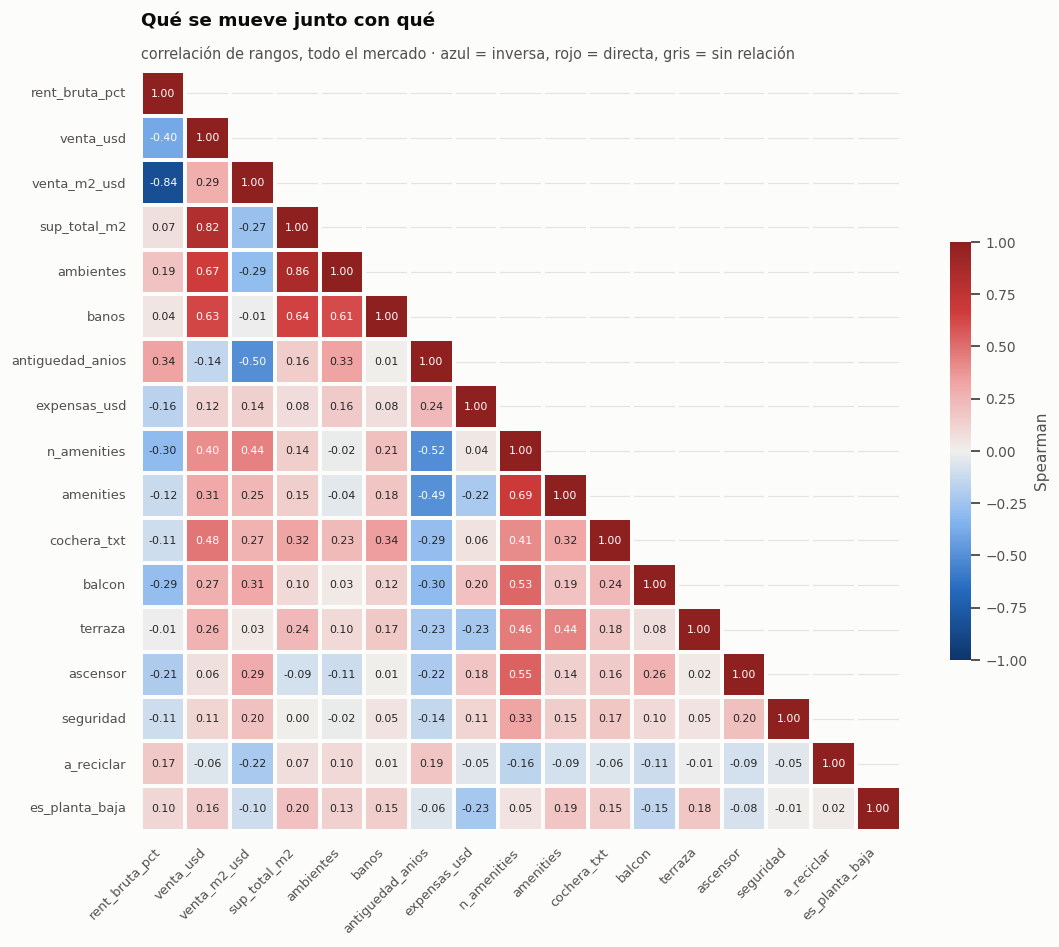

In [61]:
fig, ax = plt.subplots(figsize=(10.5, 8.6))
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mascara, cmap=eda.CMAP_DIV, center=0, vmin=-1, vmax=1,
            square=True, linewidths=1.6, linecolor=eda.SUPERFICIE,
            annot=True, fmt=".2f", annot_kws={"size": 7.2},
            cbar_kws={"shrink": 0.55, "label": "Spearman"}, ax=ax)
eda.titulo(ax, "Qué se mueve junto con qué",
           "correlación de rangos, todo el mercado · azul = inversa, rojo = directa, gris = sin relación")
plt.xticks(rotation=45, ha="right", fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
fig.tight_layout()
eda.guardar(fig, 10, "heatmap_correlacion")
plt.show()

> **Lectura.** El mapa es la vista global y la tabla de arriba es su control. Comparar las
> dos columnas separa lo que es del inmueble de lo que es de la zona.
>
> **La relación entre precio del m² y renta no es solo barrio.** Es la correlación más
> fuerte del mapa y casi no se achica dentro del estrato: aun entre propiedades del mismo
> barrio y el mismo tamaño, la que se vende más cara por m² rinde menos. H1 opera también
> adentro de cada barrio, no solo entre barrios.
>
> **Lo que era zona se desinfla.** Los atributos cuya correlación con la renta se acerca a
> cero dentro del estrato (la tabla lo muestra en cochera, seguridad y expensas) estaban
> funcionando como indicadores del barrio. Los que la conservan describen la unidad, y
> son los candidatos a importar en la elección entre dos propiedades de una misma zona.
>
> **Los atributos de confort corren juntos.** `amenities`, `seguridad`, `ascensor`,
> `cochera_txt` y `n_amenities` correlacionan entre sí: son la firma del mismo tipo de
> edificio. Para un modelo es información redundante, y agregarlas todas no multiplica el
> poder predictivo.
>
> Son correlaciones descriptivas: no establecen causalidad. El contraste formal y la
> reducción de dimensionalidad corresponden a la 3ra entrega.

### Gráfico 12 — Rentabilidad por tamaño de la unidad

> **Pregunta.** ¿Conviene comprar chico o grande? Es la decisión más concreta que enfrenta
> el cliente una vez fijado el presupuesto. La primera lectura de los datos resulta
> engañosa, y este gráfico es el ejemplo de manual de por qué hay que comparar semejantes.

In [62]:
ORDEN = S.ORDEN_SUPERFICIE_RANGO
por_tam = ok.groupby("superficie_rango", observed=True).agg(
    n=("rent_bruta_pct", "size"),
    mediana=("rent_bruta_pct", "median"),
    p25=("rent_bruta_pct", lambda s: s.quantile(.25)),
    p75=("rent_bruta_pct", lambda s: s.quantile(.75)),
    m2_med=("venta_m2_usd", "median"),
).reindex(ORDEN).dropna()
print(por_tam.round(2).to_string())
print()
comp_tam = (ok.groupby("superficie_rango", observed=True).tipo_familia
            .value_counts(normalize=True).unstack().reindex(ORDEN) * 100).round(1)
print("Composicion de cada tramo por tipo de propiedad (%):")
print(comp_tam.to_string())

                     n  mediana   p25    p75   m2_med
superficie_rango                                     
hasta 35          1031     7.20  6.39   8.08  2294.12
36-55             2598     6.92  5.98   8.09  2186.92
56-80             2242     6.74  5.90   7.93  2076.92
81-120            1626     6.82  5.81   8.00  2035.32
120+              1706     7.86  6.12  10.00  1544.26

Composicion de cada tramo por tipo de propiedad (%):
tipo_familia      casa  departamento    ph
superficie_rango                          
hasta 35           NaN          98.4   1.6
36-55              0.0          95.5   4.5
56-80              0.1          90.8   9.1
81-120             0.9          83.8  15.4
120+              24.3          50.6  25.1


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/12_box_rentabilidad_superficie.png


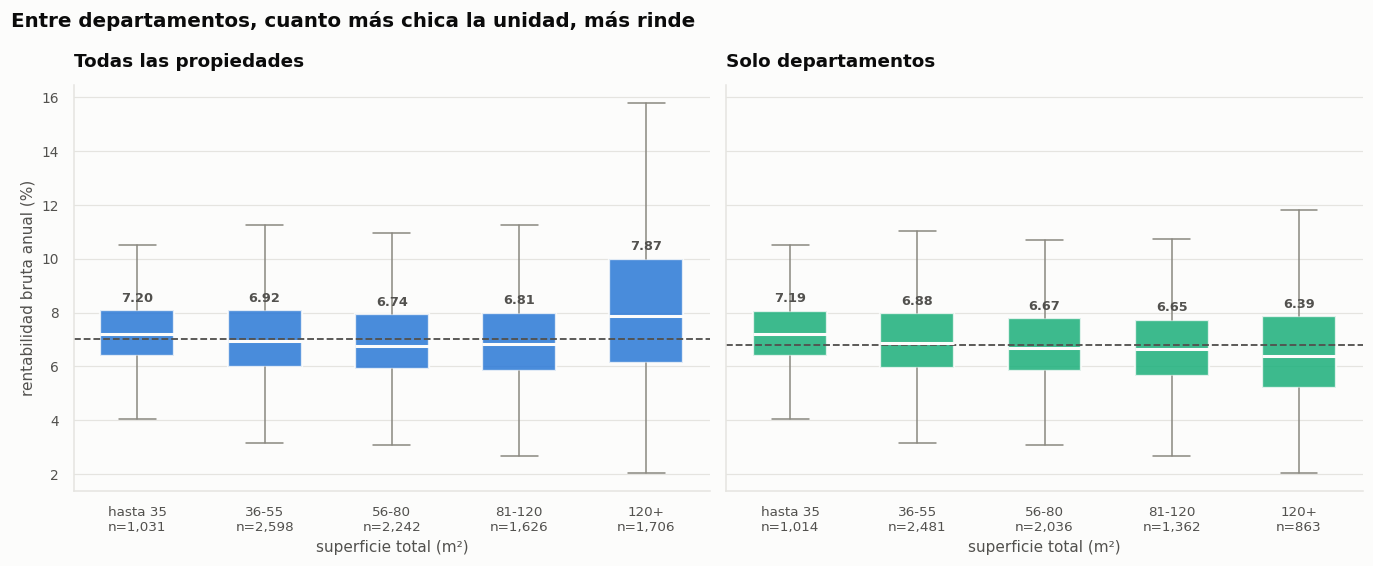

In [63]:
# Dos paneles: el mercado entero y solo departamentos. Es la forma de mostrar
# que un repunte del tramo grande, si aparece, no es un efecto del tamanio.
deptos = ok[ok.tipo_familia == "departamento"]
paneles = [("Todas las propiedades", ok, eda.SERIE_1),
           ("Solo departamentos", deptos, eda.SERIE_3)]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), sharey=True)
for ax, (titulo_p, base, color) in zip(axes, paneles):
    tramos = [t for t in ORDEN if (base.superficie_rango == t).sum() >= S.MIN_AVISOS_TRAMO]
    datos = [base.loc[base.superficie_rango == t, "rent_bruta_pct"].values for t in tramos]
    ene = [len(dd) for dd in datos]
    bp = ax.boxplot(datos, positions=range(len(tramos)), widths=0.58, patch_artist=True,
                    showfliers=False, medianprops=dict(color=eda.SUPERFICIE, linewidth=2),
                    whiskerprops=dict(color=eda.TINTA_3), capprops=dict(color=eda.TINTA_3),
                    boxprops=dict(edgecolor=eda.SUPERFICIE, linewidth=1.5))
    for caja in bp["boxes"]:
        caja.set_facecolor(color); caja.set_alpha(0.85)
    for i, dd in enumerate(datos):
        ax.text(i, np.percentile(dd, 75) + 0.32, f"{np.median(dd):.2f}", ha="center",
                fontsize=8.4, color=eda.TINTA_2, fontweight="600")
    ax.axhline(base.rent_bruta_pct.median(), color=eda.TINTA_2, linestyle="--", linewidth=1.2)
    ax.set_xticks(range(len(tramos)))
    ax.set_xticklabels([f"{t}\nn={n:,}" for t, n in zip(tramos, ene)], fontsize=8.8)
    ax.set_xlabel("superficie total (m²)")
    eda.titulo(ax, titulo_p, "")
axes[0].set_ylabel("rentabilidad bruta anual (%)")
fig.suptitle("Entre departamentos, cuanto más chica la unidad, más rinde",
             x=0.005, ha="left", fontsize=13, fontweight="600")
fig.tight_layout()
eda.guardar(fig, 12, "box_rentabilidad_superficie")
plt.show()

In [64]:
# Control dentro del barrio: la diferencia entre el tramo chico y el grande,
# medida en cada barrio que tenga los dos, entre departamentos solamente.
chico, grande = ORDEN[0], ORDEN[3]
filas = []
for barrio, g in deptos.groupby("barrio"):
    a = g.loc[g.superficie_rango == chico, "rent_bruta_pct"]
    z = g.loc[g.superficie_rango == grande, "rent_bruta_pct"]
    if len(a) >= S.MIN_GRUPO_ESTRATO and len(z) >= S.MIN_GRUPO_ESTRATO:
        filas.append({"barrio": barrio, "dif": a.median() - z.median(), "peso": min(len(a), len(z))})
ctl = pd.DataFrame(filas)
print(f"Departamentos '{chico}' menos '{grande}', dentro del mismo barrio:")
print(f"    barrios comparables : {len(ctl)}")
print(f"    diferencia mediana ponderada: {eda.mediana_ponderada(ctl.dif, ctl.peso):+.2f} pp")
print(f"    barrios donde el chico rinde mas: {(ctl.dif > 0).mean() * 100:.0f}%")
print()
print("Medianas por tramo, todas las propiedades contra solo departamentos:")
for t in ORDEN:
    a_ = ok.loc[ok.superficie_rango == t, "rent_bruta_pct"].median()
    d_ = deptos.loc[deptos.superficie_rango == t, "rent_bruta_pct"].median()
    print(f"    {t:<10} todas {a_:>5.2f}%   solo deptos {d_:>5.2f}%   diferencia {a_ - d_:+.2f} pp")

Departamentos 'hasta 35' menos '81-120', dentro del mismo barrio:
    barrios comparables : 29
    diferencia mediana ponderada: +0.34 pp
    barrios donde el chico rinde mas: 72%

Medianas por tramo, todas las propiedades contra solo departamentos:
    hasta 35   todas  7.20%   solo deptos  7.19%   diferencia +0.01 pp
    36-55      todas  6.92%   solo deptos  6.88%   diferencia +0.04 pp
    56-80      todas  6.74%   solo deptos  6.67%   diferencia +0.07 pp
    81-120     todas  6.81%   solo deptos  6.65%   diferencia +0.16 pp
    120+       todas  7.87%   solo deptos  6.39%   diferencia +1.48 pp


> **Lectura.** Mirando todas las propiedades juntas, el tramo más grande se despega del
> resto, y leído así el gráfico parecería recomendar comprar grande. Pero ese tramo es el
> único donde casas y PH tienen peso real (ver la tabla de composición), y casas y PH se
> venden a un m² mucho más barato porque incorporan terreno. **Esa mezcla, no el tamaño,
> es la que levanta la mediana del tramo.** Restringido a departamentos, la serie decrece
> de forma ordenada.
>
> El control dentro del barrio lo confirma: comparando departamentos chicos y grandes del
> **mismo barrio**, el chico rinde más en la mayoría de los barrios (el porcentaje y la
> diferencia están en la celda de arriba). Un monoambiente
> se vende a un m² parecido al de un tres ambientes del mismo edificio pero se alquila a un
> valor por m² más alto, porque el inquilino paga por tener *una* unidad.
>
> Una advertencia que el gráfico no puede mostrar: las unidades chicas rotan más de
> inquilino, y cada rotación es vacancia. El KPI neto la aproxima con una vacancia
> uniforme (`supuestos.VACANCIA_PCT`), que probablemente subestime la de los
> monoambientes.

### Gráfico 13 — Qué mueve el alquiler, según el modelo

> **Pregunta.** Los gráficos anteriores controlan por el estrato, pero de a un atributo por
> vez. **¿Qué atributos siguen importando cuando se controla por todos los otros a la
> vez?** Lo responde el modelo de estimación de alquiler, cuyos coeficientes son efectos
> parciales: el impacto de cada atributo manteniendo el resto constante.

In [65]:
bundle = joblib.load("../data/processed/modelo_alquiler.joblib")
pipe = bundle["pipeline"]
pre = pipe.named_steps["pre"]
coefs = pipe.named_steps["mod"].coef_
nombres = [n.split("__")[-1] for n in pre.get_feature_names_out()]

# El target es log(alquiler): un coeficiente b se lee como (exp(b)-1)*100 por
# ciento de variacion.
efectos = pd.Series({n: (np.exp(cf) - 1) * 100 for n, cf in zip(nombres, coefs)})
# Los coeficientes de barrio son ubicacion, no atributos: se miran aparte.
atributos = efectos[~efectos.index.str.startswith("barrio_")
                    & ~efectos.index.str.startswith("tipo_familia_")]
atributos = atributos.reindex(atributos.abs().sort_values(ascending=False).index)
print("Efecto de cada atributo sobre el alquiler estimado")
print("(dummies: por tener la caracteristica · numericas: por un desvio estandar mas)")
print()
for k, v in atributos.items():
    print(f"    {k:<24}{v:>+7.1f}%")

Efecto de cada atributo sobre el alquiler estimado
(dummies: por tener la caracteristica · numericas: por un desvio estandar mas)

    log_sup                   +30.5%
    cochera_txt               +14.6%
    ambientes                 +13.1%
    amoblado                  +12.2%
    pileta                     +9.0%
    reciclado                  +8.5%
    antiguedad_anios           -5.3%
    a_reciclar                 -5.1%
    banos                      +4.5%
    aire_acondicionado         +3.3%
    seguridad                  +2.7%
    amenities                  +2.0%
    luminoso                   +1.6%
    ascensor                   -0.9%
    parrilla                   +0.8%
    dormitorios                +0.6%
    balcon                     +0.4%
    baulera                    +0.4%
    patio_jardin               -0.0%


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/13_coeficientes_modelo.png


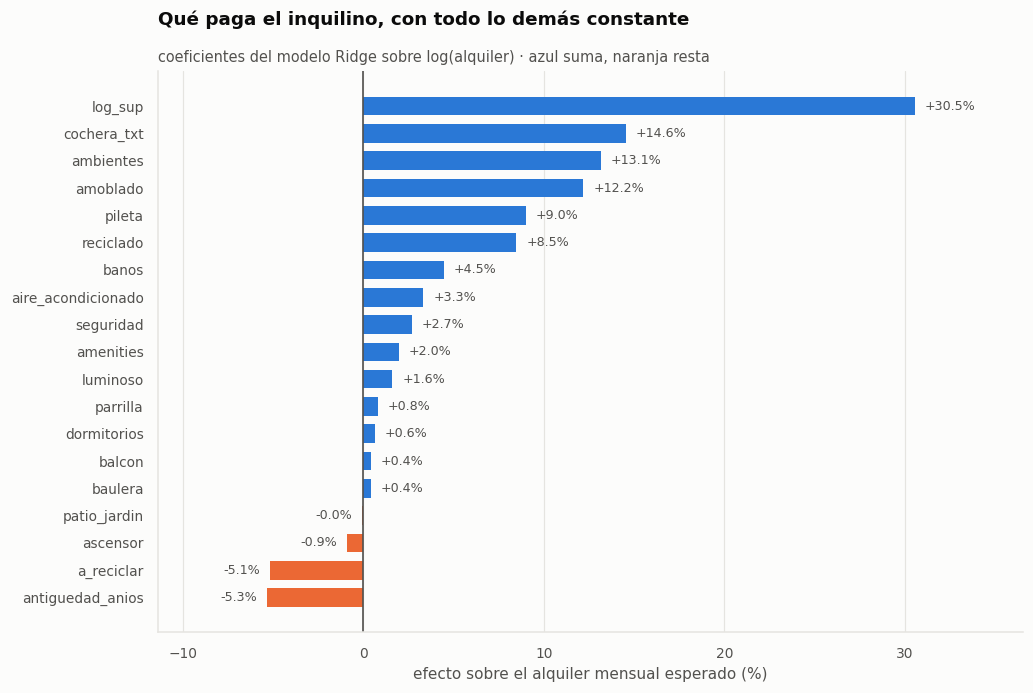

In [66]:
fig, ax = plt.subplots(figsize=(9.5, 6.4))
a = atributos.sort_values()
colores = [eda.SERIE_2 if v < 0 else eda.SERIE_1 for v in a]
ax.barh(range(len(a)), a.values, color=colores, height=0.68)
ax.axvline(0, color=eda.TINTA_2, linewidth=1.1)
ax.set_yticks(range(len(a)))
ax.set_yticklabels(a.index, fontsize=9)
for i, v in enumerate(a.values):
    off = 0.55 if v >= 0 else -0.55
    ax.text(v + off, i, f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right",
            fontsize=8.3, color=eda.TINTA_2)
ax.set_xlim(a.min() - 6, a.max() + 6)
ax.set_xlabel("efecto sobre el alquiler mensual esperado (%)")
eda.sin_grilla_y(ax)
eda.titulo(ax, "Qué paga el inquilino, con todo lo demás constante",
           "coeficientes del modelo Ridge sobre log(alquiler) · azul suma, naranja resta")
fig.tight_layout()
eda.guardar(fig, 13, "coeficientes_modelo")
plt.show()

> **Lectura.** El tamaño domina todo lo demás: ningún amenity se le acerca. Esto completa
> el gráfico 09. Allí los amenities restaban renta dentro del estrato; acá se ve que, con
> todo lo demás controlado, **su efecto sobre el alquiler es modesto**. Las dos cosas juntas
> cuentan la historia completa: los amenities suben algo el alquiler, suben bastante más el
> precio de compra, y el saldo para el inversor es negativo.
>
> Advertencia de lectura: son coeficientes de un modelo lineal regularizado sobre variables
> correlacionadas entre sí. Ridge reparte el peso entre predictoras que se superponen, así
> que el coeficiente individual de cada amenity es una aproximación y no una medición
> limpia de su efecto.

## Bloque D — ¿Qué puedo comprar, y en qué mercado?

### Gráfico 11 — El presupuesto del cliente contra la oferta real

> **Pregunta.** El cliente declara un capital dentro de la banda de presupuesto de
> `supuestos.py`. **¿Qué proporción del mercado le queda al alcance, y cómo se compara
> con lo que efectivamente se escritura en la Ciudad?**

In [67]:
PISO, TECHO = S.PRESUPUESTO_USD
venta = ok.venta_usd.dropna()
dentro = venta.between(PISO, TECHO)

colegio = pd.read_csv("../data/external/colegio_escribanos_mensual.csv", encoding="utf-8-sig")
ult = colegio.dropna(subset=["monto_promedio_usd"]).iloc[-1]
escritura = float(ult.monto_promedio_usd)

print(f"Propiedades en venta analizadas : {len(venta):,}")
print(f"    por debajo de USD {PISO:,}   : {(venta < PISO).mean()*100:>5.1f}%")
print(f"    dentro del presupuesto      : {dentro.mean()*100:>5.1f}%")
print(f"    por encima de USD {TECHO:,}  : {(venta > TECHO).mean()*100:>5.1f}%")
print()
print(f"mediana de la oferta            : USD {venta.median():>10,.0f}")
print(f"promedio de la oferta           : USD {venta.mean():>10,.0f}")
print(f"monto promedio escriturado      : USD {escritura:>10,.0f}  ({ult.mes}, Colegio de Escribanos)")
print(f"    la oferta queda por debajo de ese monto en {(venta < escritura).mean()*100:.1f}% de los casos")

Propiedades en venta analizadas : 9,203
    por debajo de USD 80,000   :  18.6%
    dentro del presupuesto      :  56.5%
    por encima de USD 200,000  :  24.9%

mediana de la oferta            : USD    134,500
promedio de la oferta           : USD    171,957
monto promedio escriturado      : USD    119,270  (2026-08, Colegio de Escribanos)
    la oferta queda por debajo de ese monto en 41.6% de los casos


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/11_ecdf_presupuesto.png


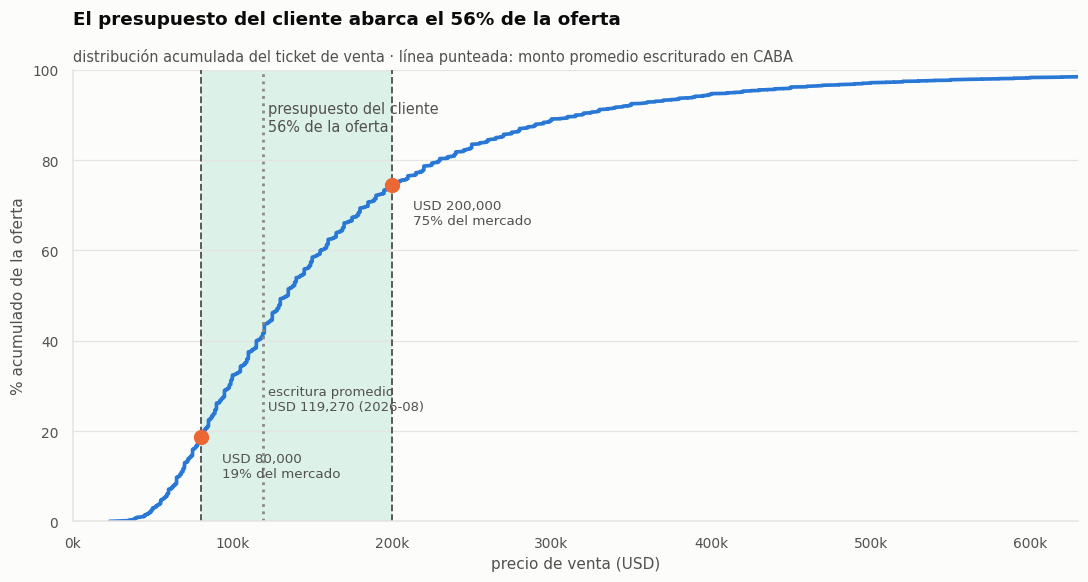

In [68]:
fig, ax = plt.subplots(figsize=(10, 5.4))
x = np.sort(venta.values)
y = np.arange(1, len(x) + 1) / len(x) * 100
ax.plot(x, y, color=eda.SERIE_1, linewidth=2.4)
ax.axvspan(PISO, TECHO, color=eda.SERIE_3, alpha=0.14, zorder=0)
for lim in (PISO, TECHO):
    ax.axvline(lim, color=eda.TINTA_2, linestyle="--", linewidth=1.2)
    pct = (venta < lim).mean() * 100
    ax.plot([lim], [pct], "o", color=eda.SERIE_2, markersize=9, zorder=4)
    ax.annotate(f"USD {lim:,.0f}\n{pct:.0f}% del mercado", (lim, pct), xytext=(14, -26),
                textcoords="offset points", fontsize=8.8, color=eda.TINTA_2)
ax.axvline(escritura, color=eda.TINTA_3, linestyle=":", linewidth=1.8)
# Las dos etiquetas van a la derecha de la linea de escrituras: a la izquierda
# chocan con la del piso del presupuesto, y centradas la linea las corta.
ax.text(escritura + 3000, 24, f"escritura promedio\nUSD {escritura:,.0f} ({ult.mes})",
        fontsize=8.6, color=eda.TINTA_2, va="bottom", ha="left")
ax.text(escritura + 3000, 93, f"presupuesto del cliente\n{dentro.mean()*100:.0f}% de la oferta",
        ha="left", va="top", fontsize=9.5, color=eda.TINTA_2)
ax.set_xlim(0, venta.quantile(S.ECDF_XMAX_CUANTIL))
ax.set_ylim(0, 100)
ax.set_xlabel("precio de venta (USD)")
ax.set_ylabel("% acumulado de la oferta")
ax.xaxis.set_major_formatter(lambda v, p: f"{v/1000:,.0f}k")
eda.titulo(ax, f"El presupuesto del cliente abarca el {dentro.mean()*100:.0f}% de la oferta",
           "distribución acumulada del ticket de venta · línea punteada: monto promedio escriturado en CABA")
fig.tight_layout()
eda.guardar(fig, 11, "ecdf_presupuesto")
plt.show()

> **Lectura.** La banda del presupuesto concentra la mayor parte de la oferta (el
> porcentaje está en la celda de arriba): el cliente no está en un nicho marginal sino en
> el tramo más poblado del mercado, con mucho para elegir. El costo de elegir mal no es no
> encontrar nada, es dejar rendimiento sobre la mesa.
>
> El monto promedio escriturado en la Ciudad cae **dentro** de la banda del presupuesto: el
> ticket del cliente es el ticket típico de las operaciones que efectivamente se cierran.
> La comparación es solo de referencia: el promedio del Colegio incluye todo tipo de
> inmueble y es un precio de cierre, mientras que la curva es de precios publicados de
> propiedades residenciales.

### Gráfico 14 — Cómo llegó el mercado hasta acá 

> **Pregunta.** El scraping es una foto de agosto de 2026 y no permite ver evolución. **¿En
> qué momento del ciclo se toma esa foto, y cuánto tarda en venderse una unidad?** Se usan
> tres series oficiales: el precio publicado del m² y el tiempo medio de publicación de
> departamentos en venta, del Instituto de Estadística de la Ciudad (trimestrales, desde
> 2017), y las escrituras de compraventa del Colegio de Escribanos (mensual). Es el
> contexto histórico que el README desarrolla en "Contexto argentino".

In [69]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

serie = pd.read_csv("../data/external/estadistica_ciudad_m2_serie.csv", encoding="utf-8-sig")
serie = serie[serie.estado == "usado"].copy()
serie["fecha"] = pd.PeriodIndex(serie.trimestre.str.replace("-T", "Q"), freq="Q").to_timestamp()
esc = colegio[colegio.mes >= serie.trimestre.min()[:4]].copy()
esc["fecha"] = pd.to_datetime(esc.mes + "-01")

for amb, g in serie.groupby("ambientes"):
    g = g.sort_values("fecha")
    minimo = g.loc[g.usd_m2.idxmin()]
    print(f"{amb} amb usado: {g.usd_m2.iloc[0]:,.0f} USD/m2 en {g.trimestre.iloc[0]}, "
          f"minimo {minimo.usd_m2:,.0f} en {minimo.trimestre}, "
          f"{g.usd_m2.iloc[-1]:,.0f} en {g.trimestre.iloc[-1]} "
          f"({(g.usd_m2.iloc[-1] / minimo.usd_m2 - 1) * 100:+.1f}% desde el minimo)")
print()
anual = esc.assign(anio=esc.mes.str[:4]).groupby("anio").agg(
    meses=("compraventas", "size"), compraventas=("compraventas", "sum"),
    hipotecas=("hipotecas", "sum"))
anual["pct_hipoteca"] = (anual.hipotecas / anual.compraventas * 100).round(1)
print(anual.to_string())
print()
print("2026 solo tiene julio y agosto: el cuadro oficial trae 2026 inconsistente con el")
print("Colegio y se descarto (ver informe/FUENTES_EXTERNAS.md).")
print()
tpub = pd.read_csv("../data/external/estadistica_ciudad_tiempo_publicacion.csv", encoding="utf-8-sig")
tpub = tpub[tpub.trimestre >= serie.trimestre.min()].copy()
tpub["fecha"] = pd.PeriodIndex(tpub.trimestre.str.replace("-T", "Q"), freq="Q").to_timestamp()
ult_t = tpub.trimestre.max()
tot = tpub[tpub.ambientes == "Total"].set_index("trimestre").dias
print(f"Tiempo medio de publicacion de departamentos en venta ({ult_t}):")
for cat, g in tpub[tpub.trimestre == ult_t].groupby("ambientes", sort=False):
    print(f"    {cat:<20}{g.dias.iloc[0]:>6.0f} dias ({g.dias.iloc[0] / 30.4:.1f} meses)")
print(f"Total: maximo de la serie {tot.max():.0f} dias en {tot.idxmax()}, "
      f"minimo {tot.min():.0f} en {tot.idxmin()}")

1 amb usado: 2,567 USD/m2 en 2017-T1, minimo 2,252 en 2023-T2, 2,561 en 2026-T2 (+13.7% desde el minimo)
2 amb usado: 2,484 USD/m2 en 2017-T1, minimo 2,085 en 2023-T3, 2,343 en 2026-T2 (+12.4% desde el minimo)
3 amb usado: 2,402 USD/m2 en 2017-T1, minimo 1,991 en 2023-T4, 2,160 en 2026-T2 (+8.5% desde el minimo)

      meses  compraventas  hipotecas  pct_hipoteca
anio                                              
2017     12         63403      14874          23.5
2018     12         55612      14048          25.3
2019     12         33431       2859           8.6
2020     12         18770        978           5.2
2021     12         28842       1634           5.7
2022     12         33771       1217           3.6
2023     12         40550       1468           3.6
2024     12         54809       4816           8.8
2025     12         69490      13288          19.1
2026      2         12106       2018          16.7

2026 solo tiene julio y agosto: el cuadro oficial trae 2026 inconsistent

In [70]:
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.07,
                    subplot_titles=("Precio publicado del m², departamentos usados (USD)",
                                    "Escrituras de compraventa por mes",
                                    "Tiempo medio de publicación de departamentos en venta (días)"))
for (amb, g), color in zip(serie.groupby("ambientes"), eda.CATEGORICA):
    g = g.sort_values("fecha")
    fig.add_trace(go.Scatter(x=g.fecha, y=g.usd_m2, mode="lines+markers",
                             name=f"{amb} ambiente{'s' if amb > 1 else ''}",
                             line=dict(color=color, width=2.4), marker=dict(size=5),
                             hovertemplate="%{x|%Y T%q}<br>USD %{y:,.0f}/m²<extra></extra>"),
                  row=1, col=1)
fig.add_trace(go.Bar(x=esc.fecha, y=esc.compraventas - esc.hipotecas, name="sin hipoteca",
                     marker_color=eda.SERIE_1, opacity=0.85,
                     hovertemplate="%{x|%b %Y}<br>%{y:,} sin hipoteca<extra></extra>"),
              row=2, col=1)
fig.add_trace(go.Bar(x=esc.fecha, y=esc.hipotecas, name="con hipoteca",
                     marker_color=eda.SERIE_2, opacity=0.9,
                     hovertemplate="%{x|%b %Y}<br>%{y:,} con hipoteca<extra></extra>"),
              row=2, col=1)
# Las mismas tres series del panel de precios, con los mismos colores.
for amb, color in zip(["1 ambiente", "2 ambientes", "3 ambientes"], eda.CATEGORICA):
    g = tpub[tpub.ambientes == amb].sort_values("fecha")
    fig.add_trace(go.Scatter(x=g.fecha, y=g.dias, mode="lines+markers", name=f"{amb} (días)",
                             line=dict(color=color, width=2, dash="dot"), marker=dict(size=4),
                             showlegend=False,
                             hovertemplate=amb + "<br>%{y:.0f} días publicados<extra></extra>"),
                  row=3, col=1)
fig.add_vline(x=pd.Timestamp("2026-08-16").value / 1e6, line_dash="dot", line_color=eda.TINTA_3)
fig.add_annotation(x=pd.Timestamp("2026-08-16"), y=1.0, yref="paper", text="scraping RE/MAX",
                   showarrow=False, font=dict(size=11, color=eda.TINTA_2), xanchor="right")
fig.update_layout(barmode="stack", height=980, plot_bgcolor=eda.SUPERFICIE,
                  paper_bgcolor=eda.SUPERFICIE,
                  font=dict(family="Segoe UI, sans-serif", size=12, color=eda.TINTA),
                  title=dict(text="El mercado de CABA, 2017–2026: precio, operaciones y tiempo de venta",
                             font=dict(size=15), x=0.01, xanchor="left"),
                  legend=dict(orientation="h", y=-0.08), margin=dict(l=70, r=30, t=90, b=60))
fig.update_xaxes(gridcolor=eda.GRILLA, zeroline=False)
fig.update_yaxes(gridcolor=eda.GRILLA, zeroline=False)

import os
os.makedirs("../graficos", exist_ok=True)
destino = "../graficos/14_evolucion_mercado.html"
pio.write_html(fig, destino, include_plotlyjs="cdn", full_html=True)
print(f"guardado: {destino}")
fig.show()

guardado: ../graficos/14_evolucion_mercado.html


> **Lectura.** La serie de precios muestra el ciclo que el scraping no puede ver: el m²
> publicado bajó durante los años de crisis, tocó un mínimo y desde ahí se recupera, sin
> volver todavía a los valores de 2017 en todas las tipologías (las cifras están en la
> celda de arriba). La foto de agosto de 2026 se toma en la fase de recuperación, no en un
> pico ni en un piso. Eso importa para leer la rentabilidad: es un cociente entre precio y
> alquiler medido en un momento del ciclo, y en otro momento daría otro número.
>
> Las escrituras cuentan la otra mitad: el volumen se recuperó con fuerza desde 2024, y la
> franja naranja muestra cuánto de eso fue crédito hipotecario. Aun en el mejor momento, la
> mayoría de las operaciones se hizo sin hipoteca, que es el rasgo del mercado de contado
> que el README describe en "Contexto argentino". Para el cliente, es el mercado donde va a
> tener que revender: **líquido en volumen, pero con compradores que pagan con ahorros
> propios**.
>
> El tercer panel pone la liquidez en números: un departamento en venta pasa, en promedio,
> **meses** publicado antes de bajarse (la cifra del último trimestre está en la celda de
> arriba). El tiempo se acortó desde su máximo, pero sigue siendo largo. Para el inversor es
> el costo de salida que la renta fija no tiene. Advertencia: es tiempo publicado, no tiempo
> de venta, y es de toda la Ciudad; el dataset no permite medirlo por propiedad.
>
> El hueco de enero a junio de 2026 es deliberado: el cuadro oficial trae esos meses con
> valores inconsistentes con el Colegio y no se usan.

### Gráfico 15 — Dónde está la oferta y dónde rinde

> **Pregunta.** Los gráficos anteriores agrupan por barrio. **¿Cómo se distribuye en el mapa
> la oferta que el cliente puede comprar, y dónde están las unidades que más rinden?** Es un
> gráfico de dispersión espacial con las coordenadas de cada aviso. No calcula distancias ni
> cruza capas geográficas: eso es fusión espacial, alcance de la 3ra entrega.

In [71]:
geo = ok.dropna(subset=["latitud", "longitud"]).copy()
geo["en_presupuesto"] = geo.venta_usd.between(*S.PRESUPUESTO_USD)
print(f"Propiedades con coordenadas: {len(geo):,} de {len(ok):,}")
# Zonas por comuna, para leer el mapa con numeros: norte (corredor de
# Palermo a Nunez), centro y sur/oeste.
ZONAS = {"norte": [2, 13, 14], "centro": [1, 3, 5, 6, 15], "sur y oeste": [4, 7, 8, 9, 10, 11, 12]}
for zona, comunas in ZONAS.items():
    z = geo[geo.comuna.isin(comunas)]
    print(f"    {zona:<12} n={len(z):>5,} ({len(z) / len(geo) * 100:4.1f}%)   "
          f"renta bruta mediana {z.rent_bruta_pct.median():5.2f}%   "
          f"en presupuesto {z.en_presupuesto.mean() * 100:5.1f}%   "
          f"neta sobre el piso de las ON {(z.rent_neta_pct >= S.RETORNO_MIN_PISO_PCT).mean() * 100:5.1f}%")

Propiedades con coordenadas: 9,198 de 9,203
    norte        n=2,768 (30.1%)   renta bruta mediana  6.26%   en presupuesto  57.1%   neta sobre el piso de las ON   4.4%
    centro       n=3,556 (38.7%)   renta bruta mediana  7.54%   en presupuesto  54.1%   neta sobre el piso de las ON  25.6%
    sur y oeste  n=2,874 (31.2%)   renta bruta mediana  7.31%   en presupuesto  58.9%   neta sobre el piso de las ON  25.3%


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/15_mapa_rentabilidad.png


findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.


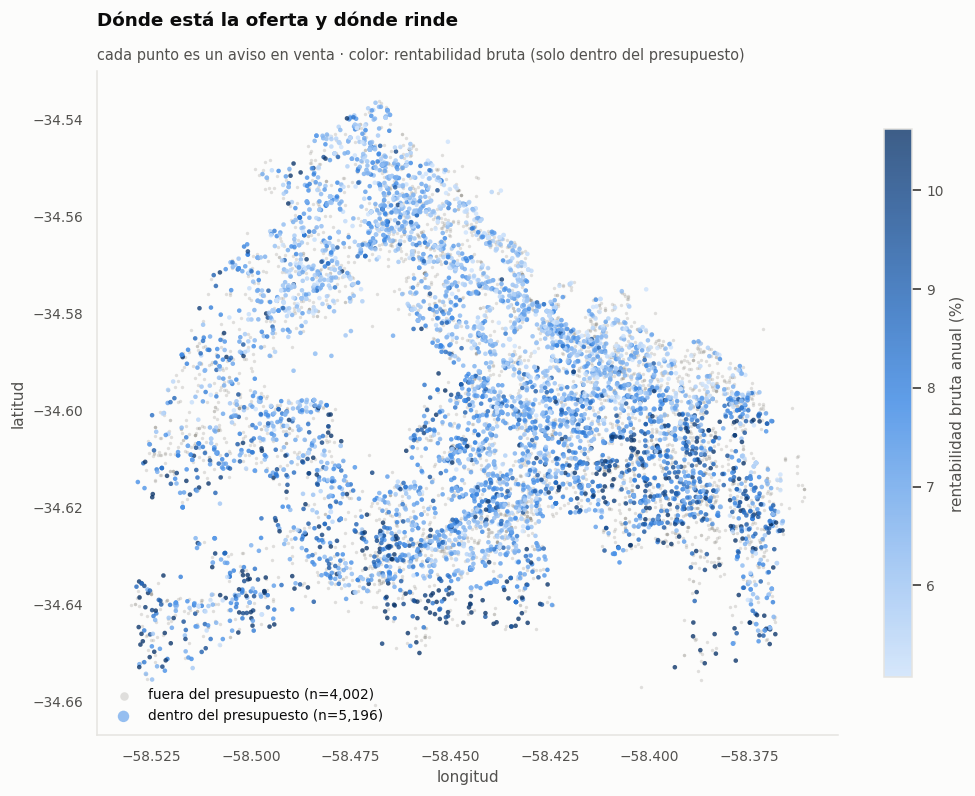

In [72]:
fig, ax = plt.subplots(figsize=(9.5, 8.6))
fuera = geo[~geo.en_presupuesto]
dentro_g = geo[geo.en_presupuesto]
ax.scatter(fuera.longitud, fuera.latitud, s=5, color=eda.TINTA_3, alpha=0.25,
           label=f"fuera del presupuesto (n={len(fuera):,})", zorder=1)
# Escala de color recortada a p5-p95: con los extremos, casi todo queda en un
# solo tono y el mapa no muestra nada.
vmin, vmax = dentro_g.rent_bruta_pct.quantile([.05, .95])
sc = ax.scatter(dentro_g.longitud, dentro_g.latitud, c=dentro_g.rent_bruta_pct, cmap=eda.CMAP_SEC,
                vmin=vmin, vmax=vmax, s=9, alpha=0.8, zorder=2,
                label=f"dentro del presupuesto (n={len(dentro_g):,})")
fig.colorbar(sc, ax=ax, shrink=0.6, label="rentabilidad bruta anual (%)")
# Un grado de longitud mide menos que uno de latitud a esta altura: sin esta
# correccion la ciudad se ve estirada.
ax.set_aspect(1 / np.cos(np.deg2rad(geo.latitud.mean())))
ax.set_xlabel("longitud")
ax.set_ylabel("latitud")
ax.grid(False)
ax.legend(loc="lower left", markerscale=2.5)
eda.titulo(ax, "Dónde está la oferta y dónde rinde",
           "cada punto es un aviso en venta · color: rentabilidad bruta (solo dentro del presupuesto)")
fig.tight_layout()
eda.guardar(fig, 15, "mapa_rentabilidad")
plt.show()

> **Lectura.** La oferta de la cartera está repartida en proporciones parecidas entre el
> corredor norte, el centro y el sur y oeste (tabla de arriba), y también la parte que cae
> dentro del presupuesto. Lo que no se reparte igual es la renta: los tonos claros se
> agrupan en el corredor norte y los oscuros en el centro, el sur y el oeste. Es H1 vista en
> el territorio.
>
> La última columna de la tabla es la que cambia la decisión: en el norte casi ninguna
> propiedad supera, en neto, el piso de las ON en dólares, mientras que en las otras dos
> zonas lo hace una fracción varias veces mayor. Para el cliente que busca renta, **el
> corredor norte queda prácticamente descartado**, y la búsqueda de las unidades que le ganan
> a la renta fija pasa por el centro y el sur y oeste, donde también cambian el perfil de
> inquilino, la liquidez de reventa y el riesgo.

## 4. Hipótesis

Cada hipótesis se evalúa con el **tamaño del efecto dentro del estrato** y su dispersión
entre celdas. No hay p-valor ni decisión sobre H₀: el contraste formal es alcance de la
3ra entrega, y para cada una se declara acá qué test lo va a hacer.

H2 (el precio del m² decrece con la distancia al subte) no se evalúa: requiere la fusión
espacial con las capas de transporte, que también es 3ra entrega.

### H1 — La rentabilidad bruta es inversamente proporcional al precio del m² del barrio

In [73]:
print(f"Spearman entre barrios, todos los tamanios : {rho:+.3f}  ({len(b)} barrios)")
print(f"Spearman dentro de cada tramo de superficie: {h1_tramos.spearman.min():+.3f} a "
      f"{h1_tramos.spearman.max():+.3f}  ({len(h1_tramos)} tramos)")
print(f"Spearman dentro del estrato (tabla del grafico 10), precio/m2 vs renta: "
      f"{comp.loc['venta_m2_usd', 'dentro_estrato']:+.3f}")

Spearman entre barrios, todos los tamanios : -0.903  (29 barrios)
Spearman dentro de cada tramo de superficie: -0.949 a -0.876  (5 tramos)
Spearman dentro del estrato (tabla del grafico 10), precio/m2 vs renta: -0.810


**Evaluación.** Efecto grande y del mismo signo en todas las vistas: entre barrios, entre
barrios del mismo tamaño y entre propiedades de una misma celda. **Respaldada.**

**Test formal para la 3ra entrega.** Test de correlación de Spearman con H₀: ρ = 0 contra
H₁: ρ < 0 (unilateral), con p-valor por permutación de los barrios, repetido dentro de
cada tramo de superficie con corrección por comparaciones múltiples.

### H3 — Los inmuebles "a reciclar" cotizan con descuento, y ese descuento es la oportunidad

Si el descuento en el precio es mayor que el que el mercado aplica al alquiler, la
rentabilidad de un inmueble a reciclar es más alta que la de uno comparable en buen
estado: esa diferencia es la "oportunidad", antes de descontar el costo de reciclarlo.

In [74]:
ventas_all = df[(df.operacion == "venta") & df.venta_m2_usd.notna()]
t3p = eda.efecto_estratificado(ventas_all, "a_reciclar", "venta_m2_usd", ESTRATO, S.MIN_GRUPO_ESTRATO)
t3r = eda.efecto_estratificado(ok, "a_reciclar", "rent_bruta_pct", ESTRATO, S.MIN_GRUPO_ESTRATO)
desc = eda.mediana_ponderada(t3p.diferencia / t3p.mediana_0 * 100, t3p.peso)
r3 = eda.resumir_efecto(t3r, len(ok))
print(f"Avisos 'a reciclar' en venta: {int(ventas_all.a_reciclar.sum()):,} "
      f"({ventas_all.a_reciclar.mean() * 100:.1f}%)")
print()
print(f"Precio del m2, a reciclar contra comparable (dentro del estrato):")
print(f"    descuento mediano ponderado: {desc:+.1f}%   en {len(t3p)} celdas; "
      f"negativo en {(t3p.diferencia < 0).mean() * 100:.0f}% de ellas")
print(f"Rentabilidad bruta, a reciclar contra comparable:")
print(f"    diferencia mediana ponderada: {r3['mediana_ponderada']:+.2f} pp   en {r3['celdas']} celdas "
      f"(p25 {r3['p25']:+.2f}, p75 {r3['p75']:+.2f})")

Avisos 'a reciclar' en venta: 521 (4.8%)

Precio del m2, a reciclar contra comparable (dentro del estrato):
    descuento mediano ponderado: -23.3%   en 35 celdas; negativo en 100% de ellas
Rentabilidad bruta, a reciclar contra comparable:
    diferencia mediana ponderada: +1.12 pp   en 30 celdas (p25 +0.55, p75 +1.52)


**Evaluación.** Se mide el descuento en el precio del m² dentro de celdas de barrio y
superficie, y la diferencia de rentabilidad bruta que deja. La dirección y el tamaño salen
de la celda de arriba; la cantidad de celdas comparables es chica, porque "a reciclar" es
una fracción menor de la oferta, así que la conclusión es **tentativa**. Aun si el
descuento se confirma, la "oportunidad" es bruta: no descuenta el costo de reciclaje, que
el dataset no tiene.

**Test formal para la 3ra entrega.** Test de Van Elteren (Mann-Whitney estratificado por
celda barrio × superficie) sobre el precio del m² y sobre la rentabilidad, con H₀: sin
diferencia entre inmuebles a reciclar y comparables.

### H4 — La antigüedad impacta más en el precio de venta que en el de alquiler

In [75]:
# Solo antiguedad OBSERVADA: la imputada es la mediana del barrio x tipo y
# fabricaria una correlacion nula.
def spearman_en_estrato(base, x, y, minimo):
    base = base[(base.antiguedad_anios_imputada == 0) & base[y].notna()]
    rs, ns = [], []
    for _, g in base.groupby(ESTRATO, observed=True):
        if len(g) >= minimo and g[x].nunique() > 1:
            rs.append(g[x].corr(g[y], method="spearman")); ns.append(len(g))
    return pd.Series(rs), pd.Series(ns)

rv, nv = spearman_en_estrato(df[df.operacion == "venta"], "antiguedad_anios", "venta_m2_usd",
                             S.MIN_CELDA_CORRELACION)
ra, na = spearman_en_estrato(df[df.operacion == "alquiler"], "antiguedad_anios",
                             "alquiler_m2_usd_mes", S.MIN_AVISOS_CELDA)
print("Spearman antiguedad vs precio por m2, dentro de celdas barrio x superficie:")
print(f"    venta    : mediana ponderada {eda.mediana_ponderada(rv, nv):+.3f}  en {len(rv)} celdas "
      f"({S.MIN_CELDA_CORRELACION}+ avisos)")
print(f"    alquiler : mediana ponderada {eda.mediana_ponderada(ra, na):+.3f}  en {len(ra)} celdas "
      f"({S.MIN_AVISOS_CELDA}+ avisos)")
print()
print("Referencia del modelo de alquiler (grafico 13), antiguedad por un desvio estandar:"
      f" {atributos.get('antiguedad_anios', np.nan):+.1f}% sobre el alquiler")

Spearman antiguedad vs precio por m2, dentro de celdas barrio x superficie:
    venta    : mediana ponderada -0.552  en 117 celdas (30+ avisos)
    alquiler : mediana ponderada -0.253  en 40 celdas (10+ avisos)

Referencia del modelo de alquiler (grafico 13), antiguedad por un desvio estandar: -5.3% sobre el alquiler


**Evaluación.** Si H4 es cierta, la antigüedad correlaciona más fuerte (más negativo) con
el precio de venta del m² que con el alquiler del m², comparando dentro de las mismas
celdas. La celda de arriba lo mide con antigüedad observada. El lado del alquiler tiene
muchas menos celdas comparables (hay muchos menos alquileres que ventas), así que su estimación
es más inestable y la conclusión es **tentativa**. Si se confirma, es el mecanismo por el
que las propiedades viejas rinden más: la antigüedad abarata la compra más de lo que baja
el alquiler.

**Test formal para la 3ra entrega.** Dos regresiones, log(precio del m²) y log(alquiler
del m²), con la antigüedad como regresora y efectos fijos de celda barrio × superficie; H₀:
los dos coeficientes de antigüedad son iguales, contrastada con un test de Wald sobre la
diferencia (errores estándar por bootstrap, porque las muestras son independientes y de
distinto tamaño).

## 5. Fuentes externas

Este notebook usa cuatro fuentes externas integradas: IDECBA (precio del m² y tiempo de
publicación), Colegio de Escribanos, Inside Airbnb y Censo 2022. El catálogo de cada una
—fuente concreta, cobertura, período, granularidad, mecanismo de unión, variable
derivada, análisis al que aporta y limitaciones— está en
[`informe/FUENTES_EXTERNAS.md`](../informe/FUENTES_EXTERNAS.md), junto con las fuentes
planificadas para la 3ra entrega.


## Resumen de hallazgos

Cada resultado, con el número que lo respalda calculado en la celda siguiente.

In [76]:
hallazgos = [
    ("Asimetria",
     f"{int((resumen.asimetria.abs() >= 1).sum())} de {len(resumen)} variables continuas "
     f"tienen asimetria fuerte: se reportan medianas"),
    ("Estrato de comparacion",
     f"barrio x superficie cubre {eda.cobertura_estratos(ok, ESTRATO, S.MIN_AVISOS_CELDA)['pct_cubierto']:.1f}% "
     f"de la base con celdas de {S.MIN_AVISOS_CELDA}+ avisos"),
    ("Dispersion intra vs entre barrios",
     f"IQR maximo intra-barrio {barrios.IQR.max():.2f} pp ({barrios.IQR.idxmax()}) contra "
     f"{barrios.mediana.max() - barrios.mediana.min():.2f} pp entre barrios; se sostiene por tramo"),
    ("H1 precio vs rentabilidad",
     f"Spearman {rho:+.3f} sobre {len(b)} barrios; {h1_tramos.spearman.max():+.3f} o menos en cada tramo"),
    ("Sesgo de RE/MAX",
     f"publica mas barato que Argenprop en {(sp.desvio_pct < 0).mean() * 100:.0f}% de las celdas "
     f"(mediana {sp.desvio_pct.median():+.1f}%)"),
    ("Ladrillo contra renta fija",
     f"neta mediana {ok.rent_neta_pct.median():.2f}% contra piso de ON {piso:.2f}%; "
     f"solo {(ok.rent_neta_pct >= piso).mean() * 100:.1f}% de las propiedades lo supera"),
    ("Alquiler temporal",
     f"le gana al tradicional en {int(tv.gana_temporal_base.sum())} de {len(tv)} celdas con la "
     f"ocupacion estimada y en {int(tv.gana_temporal_ref.sum())} con {S.OCUPACION_REF_PCT:.0f}%"),
    ("Amenities, comparando semejantes",
     f"{r_am['mediana_ponderada']:+.2f} pp dentro de barrio x superficie "
     f"({r_amt['mediana_ponderada']:+.2f} con tipo fijo) contra {ingenua:+.2f} pp ingenuo"),
    ("Tamanio",
     f"entre departamentos del mismo barrio, '{chico}' rinde "
     f"{eda.mediana_ponderada(ctl.dif, ctl.peso):+.2f} pp respecto de '{grande}'"),
    ("Presupuesto del cliente",
     f"{dentro.mean()*100:.1f}% de la oferta esta en USD {PISO // 1000}k-{TECHO // 1000}k; "
     f"la escritura promedio (USD {escritura:,.0f}) cae dentro"),
    ("Liquidez",
     f"un departamento en venta pasa en promedio {tot[ult_t]:.0f} dias publicado ({ult_t}, "
     f"toda la Ciudad); el maximo de la serie fue {tot.max():.0f}"),
    ("Mapa",
     f"en el norte {(geo[geo.comuna.isin(ZONAS['norte'])].rent_neta_pct >= piso).mean() * 100:.1f}% "
     f"de las propiedades supera en neto el piso de las ON; en el sur y oeste, "
     f"{(geo[geo.comuna.isin(ZONAS['sur y oeste'])].rent_neta_pct >= piso).mean() * 100:.1f}%"),
    ("Incertidumbre",
     f"{solapan:.1f}% de las propiedades no se distinguen de la mediana del mercado"),
]
for titulo_h, texto in hallazgos:
    print(f"  {titulo_h}")
    print(f"      {texto}")
    print()

  Asimetria
      7 de 10 variables continuas tienen asimetria fuerte: se reportan medianas

  Estrato de comparacion
      barrio x superficie cubre 99.4% de la base con celdas de 10+ avisos

  Dispersion intra vs entre barrios
      IQR maximo intra-barrio 3.89 pp (barracas) contra 3.95 pp entre barrios; se sostiene por tramo

  H1 precio vs rentabilidad
      Spearman -0.903 sobre 29 barrios; -0.876 o menos en cada tramo

  Sesgo de RE/MAX
      publica mas barato que Argenprop en 94% de las celdas (mediana -9.6%)

  Ladrillo contra renta fija
      neta mediana 5.67% contra piso de ON 7.10%; solo 19.1% de las propiedades lo supera

  Alquiler temporal
      le gana al tradicional en 0 de 47 celdas con la ocupacion estimada y en 3 con 53%

  Amenities, comparando semejantes
      -0.55 pp dentro de barrio x superficie (-0.64 con tipo fijo) contra -0.49 pp ingenuo

  Tamanio
      entre departamentos del mismo barrio, 'hasta 35' rinde +0.34 pp respecto de '81-120'

  Presupuesto del 

### Lo que este notebook no hace

- **No establece causalidad.** Comparar dentro del estrato controla por zona, tamaño y
  tipología, pero no por todo: sigue siendo asociación descriptiva.
- **No contrasta hipótesis formalmente.** No hay p-valores ni decisiones sobre H₀; cada
  hipótesis declara el test que la va a contrastar en la 3ra entrega.
- **No mide revalorización.** El dataset es un corte temporal único: el trabajo estima
  renta, no retorno total. El gráfico 14 da el contexto del ciclo, no una proyección.
- **No describe el mercado completo de CABA**, sino la cartera de una red inmobiliaria,
  cuyo sesgo de precio y de composición se cuantifica en el gráfico 07.

## Síntesis del EDA

**Principales hallazgos.** Son los de la tabla de arriba. Su lectura para el inversor está
en las secciones 1 a 5 del [informe de hallazgos](../informe/INFORME_HALLAZGOS.md): la
renta neta mediana queda por debajo de la de un bono corporativo en dólares, el alquiler
temporal no la rescata y la propiedad elegida pesa tanto como el barrio.

**Problemas de calidad detectados.** Avisos duplicados del mismo inmueble, tipologías fuera
del alcance, valores imposibles, errores de moneda en la carga, nulos de distinta
naturaleza, antigüedades negativas y unidades con tantos dormitorios como ambientes.
Detalle en el [notebook 01](01_limpieza_y_calidad.ipynb), secciones 1 a 3.

**Decisiones de limpieza.** Se excluyen 2.770 filas, cada una con su motivo, se corrigen 6
y se imputan 450 por mediana de grupo. El dataset limpio queda en 12.097 filas (81,4% del
crudo). El tipo de cambio es de ARS 1.500, el promedio de agosto de 2026 del BCRA
(Com. A 3500). Resumen en la tabla final del [notebook 01](01_limpieza_y_calidad.ipynb).

**Hipótesis con evidencia preliminar.** H1 y H3 respaldadas, H4 tentativa (sección 4 de
este notebook y [§6 del informe](../informe/INFORME_HALLAZGOS.md)).

**Hipótesis que aún no pueden evaluarse.** H2, sobre la distancia al subte: requiere la
fusión espacial con las capas de BA Data, planificada en
[`FUENTES_EXTERNAS.md`](../informe/FUENTES_EXTERNAS.md).

**Limitaciones del dataset.** Las de la sección anterior: una sola fuente, un corte único,
precios de publicación y no de cierre, y una relación de 8 ventas por alquiler que obliga
a estimar el alquiler con un modelo.

**Próximos pasos.** El contraste formal de H1, H3 y H4 con los tests declarados en la
sección 4, la fusión espacial para H2, la revisión del modelo de alquiler (incluida la
coherencia de `dormitorios`) y la reducción de dimensionalidad de los atributos. El plan
completo está en el [README](../README.md#plan-para-lo-pendiente).
